# Peak Detection Methods Comparison
## Chen 2004 Yeast Cell Cycle Model Analysis

This notebook compares eight different peak detection methods:
1. **Original Method**: Basic prominence-based peak detection
2. **Improved Method**: Multi-scale + Fourier backup
3. **Conservative Method**: Strict regularity requirements
4. **Simple Method**: Ultra-basic local maxima detection
5. **Threshold Method**: Percentile-based peak finding
6. **Derivative Method**: Zero-crossing in first derivative
7. **Adaptive Method**: Parameters adapt to signal characteristics
8. **Sliding Window Method**: Local maxima in moving windows

We analyze frequency-complexity relationships and show the most/least complex oscillations for different genotypes.

In [58]:
# === IMPORTS AND SETUP ===
import tellurium as te
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import platform
import roadrunner
import math
import multiprocessing as mp
from multiprocessing import Pool, cpu_count
from collections import Counter
import time
from datetime import datetime, timedelta
from scipy.signal import find_peaks, savgol_filter
from scipy.fft import fft, fftfreq
import psutil
import warnings
warnings.filterwarnings('ignore')

# Silence RoadRunner
roadrunner.Logger.setLevel(roadrunner.Logger.LOG_CRITICAL)

# === CPU OPTIMIZATION DETECTION ===
def detect_cpu_config():
    """Detect optimal CPU configuration for Radeon/AMD processors"""
    cpu_count_total = cpu_count()
    cpu_info = platform.processor()
    
    # Check if this is an AMD/Radeon CPU
    is_amd = any(keyword in cpu_info.lower() for keyword in ['amd', 'radeon', 'ryzen', 'epyc', 'athlon'])
    
    if is_amd:
        # AMD CPUs often benefit from using physical cores only
        try:
            physical_cores = psutil.cpu_count(logical=False)
            logical_cores = psutil.cpu_count(logical=True)
            
            # For AMD, often best to use 75-85% of physical cores for compute-heavy tasks
            optimal_workers = max(1, int(physical_cores * 0.8)) if physical_cores else max(1, int(cpu_count_total * 0.7))
            
            print(f"🔧 AMD/Radeon CPU detected: {cpu_info}")
            print(f"   Physical cores: {physical_cores}, Logical cores: {logical_cores}")
            print(f"   Optimal workers for simulation: {optimal_workers}")
            
            return optimal_workers, True
        except:
            # Fallback if psutil fails
            optimal_workers = max(1, int(cpu_count_total * 0.7))
            print(f"🔧 AMD CPU detected (fallback): using {optimal_workers} workers")
            return optimal_workers, True
    else:
        # Non-AMD CPU: use standard approach
        optimal_workers = max(1, cpu_count_total - 1)
        print(f"🔧 Non-AMD CPU: using {optimal_workers} workers")
        return optimal_workers, False

OPTIMAL_WORKERS, IS_AMD_CPU = detect_cpu_config()

print("✓ All imports loaded successfully")
print(f"🔧 CPU workers: {OPTIMAL_WORKERS}")
print(f"🔧 AMD/Radeon optimization: {IS_AMD_CPU}")

🔧 Non-AMD CPU: using 11 workers
✓ All imports loaded successfully
🔧 CPU workers: 11
🔧 AMD/Radeon optimization: False


In [81]:
import numpy as np, scipy, pandas as pd, matplotlib
import statsmodels.api as sm
import skimage, pywt
from scipy import signal
print("OK: numpy", np.__version__,
      "scipy", scipy.__version__,
      "pandas", pd.__version__,
      "matplotlib", matplotlib.__version__)
try:
    import mne
    print("OK: mne", mne.__version__)
except Exception as e:
    print("MISSING/OPTIONAL: mne —", e)
try:
    from astropy.timeseries import LombScargle
    print("OK: astropy LombScargle")
except Exception as e:
    print("MISSING/OPTIONAL: astropy —", e)
try:
    from PyEMD import EMD
    print("OK: emd (PyEMD)")
except Exception as e:
    print("MISSING/OPTIONAL: PyEMD/EMD-signal —", e)
try:
    import librosa
    print("OK: librosa", librosa.__version__)
except Exception as e:
    print("MISSING/OPTIONAL: librosa —", e)


OK: numpy 1.26.4 scipy 1.13.1 pandas 2.3.1 matplotlib 3.9.4
OK: mne 1.7.1
OK: astropy LombScargle
OK: emd (PyEMD)
OK: librosa 0.10.2.post1


In [ ]:
# === CONFIGURATION ===
# Model path setup
def get_model_path():
    """Get the correct path to the SBML model file"""
    linux_path = "/home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen2004_biomd56.xml"
    mac_path = "/Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen2004_biomd56.xml"
    
    if os.path.exists(linux_path):
        return linux_path
    elif os.path.exists(mac_path):
        return mac_path
    else:
        raise FileNotFoundError(f"Could not find chen2004_biomd56.xml")

# Configuration parameters
model_path = get_model_path()
multipliers = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]
DIVERGENCE_THRESHOLD = 25
MAX_PERIOD_THRESHOLD = 300
SIMULATION_TIME = 1000
SIMULATION_POINTS = 1001
SAMPLING_SIZE = 10000  # Optimized for comparison study
N_EXAMPLES_PER_METHOD = 10  # Number of examples to analyze in detail

# Calculate optimal chunk sizee
CHUNK_SIZE = max(100, SAMPLING_SIZE // (OPTIMAL_WORKERS * 10))

# AMD/Radeon specific optimizations
if IS_AMD_CPU:
    # AMD CPUs often benefit from smaller chunks to reduce cache pressure
    CHUNK_SIZE = max(50, CHUNK_SIZE // 2)
    # Enable AMD-specific optimizations
    os.environ['OMP_NUM_THREADS'] = str(OPTIMAL_WORKERS)
    os.environ['MKL_NUM_THREADS'] = str(OPTIMAL_WORKERS)
    os.environ['NUMEXPR_NUM_THREADS'] = str(OPTIMAL_WORKERS)

print(f"✓ Configuration loaded")
print(f"   - Model: {model_path}")
print(f"   - Sampling size: {SAMPLING_SIZE:,}")
print(f"   - Examples per method: {N_EXAMPLES_PER_METHOD}")
print(f"   - Chunk size: {CHUNK_SIZE}")
print(f"   - 🔧 CPU Type: {'AMD/Radeon optimized' if IS_AMD_CPU else 'Standard'}")
print(f"   - 🔧 Workers: {OPTIMAL_WORKERS}")

✓ Configuration loaded
   - Model: /home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen2004_biomd56.xml
   - Sampling size: 10,000
   - Examples per method: 10
   - Chunk size: 100
   - 🔧 CPU Type: Standard
   - 🔧 Workers: 11


In [61]:
# === CPU OPTIMIZATION TEST ===
print("\n🧪 Testing multiprocessing functionality...")
print(f"Detected CPU workers: {OPTIMAL_WORKERS}")
print(f"AMD/Radeon optimization: {IS_AMD_CPU}")
print(f"Total CPU cores: {mp.cpu_count()}")

# Quick multiprocessing test
def test_worker(x):
    return x ** 2

try:
    with mp.Pool(2) as pool:
        test_result = pool.map(test_worker, [1, 2, 3, 4])
    print(f"✅ Multiprocessing test successful: {test_result}")
    print("✅ Ready for parallel peak detection analysis!")
except Exception as e:
    print(f"❌ Multiprocessing test failed: {e}")
    print("⚠️  Will fall back to serial processing")

print(f"🎯 CPU Optimization Status:")
print(f"   - Workers: {OPTIMAL_WORKERS}")
print(f"   - AMD optimized: {IS_AMD_CPU}")
print(f"   - Environment configured: {'✅' if IS_AMD_CPU else '🔧'}")

if IS_AMD_CPU:
    print(f"   - OMP_NUM_THREADS: {os.environ.get('OMP_NUM_THREADS', 'Not set')}")
    print(f"   - MKL_NUM_THREADS: {os.environ.get('MKL_NUM_THREADS', 'Not set')}")
    print(f"   - NUMEXPR_NUM_THREADS: {os.environ.get('NUMEXPR_NUM_THREADS', 'Not set')}")


🧪 Testing multiprocessing functionality...
Detected CPU workers: 11
AMD/Radeon optimization: False
Total CPU cores: 12
✅ Multiprocessing test successful: [1, 4, 9, 16]
✅ Ready for parallel peak detection analysis!
🎯 CPU Optimization Status:
   - Workers: 11
   - AMD optimized: False
   - Environment configured: 🔧
✅ Multiprocessing test successful: [1, 4, 9, 16]
✅ Ready for parallel peak detection analysis!
🎯 CPU Optimization Status:
   - Workers: 11
   - AMD optimized: False
   - Environment configured: 🔧


In [62]:
# === CORE FUNCTIONS ===
def get_kinetic_parameters(rr):
    """Get list of kinetic parameters, excluding regulatory switches/flags."""
    kinetic_params = []
    excluded_params = []
    
    for pid in rr.getGlobalParameterIds():
        value = rr.getValue(pid)
        param_lower = pid.lower()
        
        # Exclude non-kinetic parameters
        if (param_lower.endswith('t') and value in [0.0, 1.0]) or \
           (param_lower.startswith('d') and param_lower.endswith('n')) or \
           ('flag' in param_lower) or \
           ('switch' in param_lower) or \
           (value == 0.0) or \
           (pid in ['cell']) or \
           ('total' in param_lower and value in [0.0, 1.0]):
            excluded_params.append(pid)
        else:
            kinetic_params.append(pid)
    
    return kinetic_params, excluded_params

def sample_parameters(rr, wildtype=False):
    """Sample kinetic parameters with random multipliers"""
    rr.resetAll()
    kinetic_params, excluded_params = get_kinetic_parameters(rr)
    
    sampled = {}
    sampled_values = []
    
    if wildtype:
        return sampled, sampled_values
    
    for pid in kinetic_params:
        try:
            current = rr.getValue(pid)
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled[pid] = factor
            sampled_values.append(factor)
        except RuntimeError:
            continue
    
    return sampled, sampled_values

def simulate_basic(rr):
    """Basic simulation with divergence checking"""
    rr.selections = ["time", "CLB2"]
    try:
        result = rr.simulate(0, SIMULATION_TIME, SIMULATION_POINTS)
    except RuntimeError:
        return None, None
    
    time = result[:, 0]
    clb2 = result[:, 1]
    
    # Check for divergence
    if np.any(np.abs(clb2) > DIVERGENCE_THRESHOLD):
        return "divergent", None
    
    return time, clb2

def lz76_phrase_count(s: str) -> int:
    """Lempel-Ziv 76 phrase count"""
    n = len(s)
    if n == 0:
        return 0
    i = 0
    c = 1
    k = 1
    while i + k <= n:
        if s[i:i+k] in s[:i]:
            k += 1
            if i + k - 1 > n:
                c += 1
                break
        else:
            c += 1
            i += k
            k = 1
    return c

def CLZ(x):
    """Lempel-Ziv complexity"""
    n = len(x)
    if x.count('0') == n or x.count('1') == n:
        return math.log2(n)
    else:
        return math.log2(n) / 2 * (lz76_phrase_count(x) + lz76_phrase_count(x[::-1]))

def up_down_encoding_paper_method(coarse_time, coarse_signal):
    """Convert coarse-grained signal to binary up/down encoding"""
    slopes = np.diff(coarse_signal) / np.diff(coarse_time)
    encoding = ''.join(['1' if s > 0 else '0' for s in slopes])
    return encoding

print("✓ Core functions defined")

✓ Core functions defined


In [63]:
# === PEAK DETECTION METHOD 1: ORIGINAL ===
def estimate_period_original(time, signal, require_peaks=3, center_on_peak=True, coarse_bins=50):
    """Original peak detection method from the base code"""
    time = np.asarray(time)
    signal = np.asarray(signal)

    # Basic peak detection
    dynamic_prom = 0.05 * (np.max(signal) - np.min(signal))
    peaks, props = find_peaks(signal, prominence=dynamic_prom, distance=len(time)//100)

    if len(peaks) < require_peaks:
        return None, (None, None)

    # Compute periods
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    mean_period = np.mean(periods)
    
    if len(periods) < 2:
        return None, (None, None)

    # Assess regularity
    cv_period = np.std(periods) / mean_period
    amplitudes = signal[peaks]
    cv_amplitude = np.std(amplitudes) / np.mean(amplitudes)

    if cv_period > 0.3 or cv_amplitude > 0.3:
        return None, (None, None)

    # Extract cycle
    if center_on_peak:
        mid_peak = peaks[-2]
        half_period = 0.5 * mean_period
        t_start = time[mid_peak] - half_period 
        t_end = time[mid_peak] + half_period 
        t_start = max(time[0], t_start)
        t_end = min(time[-1], t_end)
    else:
        start_peak = peaks[-2]
        end_peak = peaks[-1]
        t_start, t_end = time[start_peak], time[end_peak]

    mask = (time >= t_start) & (time <= t_end)
    cycle_time = time[mask]
    cycle_signal = signal[mask]

    if len(cycle_time) < 5:
        return None, (None, None)

    # Resample to coarse grid
    coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
    coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)

    return mean_period, (coarse_time, coarse_signal)

print("✓ Original peak detection method defined")

✓ Original peak detection method defined


In [64]:
# === PEAK DETECTION METHOD 2: IMPROVED ===
def estimate_period_improved(time, signal, require_peaks=3, center_on_peak=True, coarse_bins=50):
    """Improved peak detection with multi-scale and Fourier backup"""
    time = np.asarray(time)
    signal = np.asarray(signal)
    
    # Adaptive smoothing
    signal_std = np.std(signal)
    signal_range = np.max(signal) - np.min(signal)
    noise_ratio = signal_std / signal_range
    
    if noise_ratio > 0.1:
        window_length = min(31, len(signal) // 10)
        if window_length % 2 == 0:
            window_length += 1
        if window_length >= 5:
            signal_smooth = savgol_filter(signal, window_length, 3)
        else:
            signal_smooth = signal
    else:
        signal_smooth = signal
    
    # Multi-scale peak detection
    peak_candidates = []
    prominence_factors = [0.02, 0.05, 0.1, 0.15]
    
    for prom_factor in prominence_factors:
        dynamic_prom = prom_factor * (np.max(signal_smooth) - np.min(signal_smooth))
        min_distance = max(5, len(time) // 200)
        
        peaks, props = find_peaks(signal_smooth, 
                                prominence=dynamic_prom, 
                                distance=min_distance,
                                width=2)
        
        if len(peaks) >= require_peaks:
            peak_candidates.append((peaks, props, prom_factor))
    
    # Fourier backup
    fourier_period = None
    if len(signal) > 50:
        dt = np.mean(np.diff(time))
        freqs = fftfreq(len(signal), dt)
        fft_signal = np.abs(fft(signal))
        
        positive_freqs = freqs[1:len(freqs)//2]
        positive_fft = fft_signal[1:len(fft_signal)//2]
        
        if len(positive_freqs) > 0:
            dominant_freq_idx = np.argmax(positive_fft)
            dominant_freq = positive_freqs[dominant_freq_idx]
            if dominant_freq > 0:
                fourier_period = 1.0 / dominant_freq
    
    # Select best peaks
    best_peaks = None
    best_score = -1
    
    for peaks, props, prom_factor in peak_candidates:
        if len(peaks) < require_peaks:
            continue
            
        peak_times = time[peaks]
        periods = np.diff(peak_times)
        amplitudes = signal_smooth[peaks]
        
        if len(periods) < 2:
            continue
            
        cv_period = np.std(periods) / np.mean(periods) if np.mean(periods) > 0 else 1.0
        cv_amplitude = np.std(amplitudes) / np.mean(amplitudes) if np.mean(amplitudes) > 0 else 1.0
        
        regularity_score = 1.0 / (1.0 + cv_period + cv_amplitude)
        prominence_score = 1.0 / (1.0 + abs(prom_factor - 0.05))
        
        total_score = regularity_score * prominence_score
        
        if total_score > best_score:
            best_score = total_score
            best_peaks = peaks
    
    # Fourier fallback
    if best_peaks is None or len(best_peaks) < require_peaks:
        if fourier_period is not None and 10 < fourier_period < 500:
            estimated_n_peaks = int(time[-1] / fourier_period) + 1
            if estimated_n_peaks >= require_peaks:
                synthetic_peak_times = np.arange(fourier_period/2, time[-1], fourier_period)
                synthetic_peaks = []
                for peak_time in synthetic_peak_times:
                    idx = np.argmin(np.abs(time - peak_time))
                    synthetic_peaks.append(idx)
                best_peaks = np.array(synthetic_peaks)
        
        if best_peaks is None:
            return None, (None, None)
    
    # Compute final period
    peak_times = time[best_peaks]
    periods = np.diff(peak_times)
    mean_period = np.mean(periods)
    
    if len(periods) < 2:
        return None, (None, None)
    
    # More lenient thresholds
    cv_period = np.std(periods) / mean_period
    if cv_period > 0.5:
        return None, (None, None)
    
    # Extract cycle
    if len(best_peaks) < 2:
        return None, (None, None)
    
    start_peak = best_peaks[-2]
    end_peak = best_peaks[-1]
    
    if center_on_peak:
        mid_peak = start_peak
        half_period = 0.5 * mean_period
        t_start = time[mid_peak] - half_period 
        t_end = time[mid_peak] + half_period 
        t_start = max(time[0], t_start)
        t_end = min(time[-1], t_end)
    else:
        t_start, t_end = time[start_peak], time[end_peak]

    mask = (time >= t_start) & (time <= t_end)
    cycle_time = time[mask]
    cycle_signal = signal[mask]

    if len(cycle_time) < 5:
        return None, (None, None)

    coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
    coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)

    return mean_period, (coarse_time, coarse_signal)

print("✓ Improved peak detection method defined")

✓ Improved peak detection method defined


In [65]:
# === PEAK DETECTION METHOD 3: CONSERVATIVE ===
def estimate_period_conservative(time, signal, require_peaks=4, center_on_peak=True, coarse_bins=50):
    """Conservative peak detection with strict regularity requirements"""
    time = np.asarray(time)
    signal = np.asarray(signal)

    # Apply smoothing
    if len(signal) > 21:
        signal_smooth = savgol_filter(signal, 21, 3)
    else:
        signal_smooth = signal

    # Conservative peak detection
    dynamic_prom = 0.1 * (np.max(signal_smooth) - np.min(signal_smooth))  # Higher prominence
    min_distance = len(time) // 50  # Larger minimum distance
    
    peaks, props = find_peaks(signal_smooth, 
                            prominence=dynamic_prom, 
                            distance=min_distance,
                            width=5)  # Require wider peaks

    if len(peaks) < require_peaks:
        return None, (None, None)

    # Strict regularity assessment
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    mean_period = np.mean(periods)
    
    if len(periods) < 3:  # Require more periods
        return None, (None, None)

    # Very strict thresholds
    cv_period = np.std(periods) / mean_period
    amplitudes = signal_smooth[peaks]
    cv_amplitude = np.std(amplitudes) / np.mean(amplitudes)

    if cv_period > 0.15 or cv_amplitude > 0.15:  # Much stricter
        return None, (None, None)
    
    # Additional quality checks
    # Check that peaks are well-separated in amplitude
    min_amp = np.min(amplitudes)
    max_amp = np.max(amplitudes)
    if (max_amp - min_amp) / max_amp > 0.3:  # Amplitude variation too high
        return None, (None, None)
    
    # Check period consistency
    median_period = np.median(periods)
    if np.any(np.abs(periods - median_period) / median_period > 0.2):  # Any period deviates >20%
        return None, (None, None)

    # Extract most stable cycle (middle one)
    if len(peaks) >= 4:
        mid_idx = len(peaks) // 2
        start_peak = peaks[mid_idx - 1]
        end_peak = peaks[mid_idx]
    else:
        start_peak = peaks[-2]
        end_peak = peaks[-1]
    
    if center_on_peak:
        mid_peak = start_peak
        half_period = 0.5 * mean_period
        t_start = time[mid_peak] - half_period 
        t_end = time[mid_peak] + half_period 
        t_start = max(time[0], t_start)
        t_end = min(time[-1], t_end)
    else:
        t_start, t_end = time[start_peak], time[end_peak]

    mask = (time >= t_start) & (time <= t_end)
    cycle_time = time[mask]
    cycle_signal = signal[mask]

    if len(cycle_time) < 10:  # Require more points
        return None, (None, None)

    coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
    coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)

    return mean_period, (coarse_time, coarse_signal)

print("✓ Conservative peak detection method defined")

✓ Conservative peak detection method defined


In [66]:
# === PEAK DETECTION METHOD 4: SIMPLE ===
def estimate_period_simple(time, signal, require_peaks=3, center_on_peak=True, coarse_bins=50):
    """
    Ultra-simple peak detection method focusing on reliability over sophistication.
    
    Strategy:
    1. Find local maxima using basic criteria
    2. Use minimal filtering
    3. Accept wider variation in regularity
    4. Focus on finding ANY reasonable oscillation
    """
    time = np.asarray(time)
    signal = np.asarray(signal)
    
    if len(signal) < 20:
        return None, (None, None)
    
    # Simple approach: find local maxima
    # A point is a peak if it's higher than its neighbors
    peaks = []
    for i in range(1, len(signal) - 1):
        # Simple local maximum check
        if signal[i] > signal[i-1] and signal[i] > signal[i+1]:
            peaks.append(i)
    
    peaks = np.array(peaks)
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Filter peaks by minimum separation (avoid tiny fluctuations)
    min_separation = len(time) // 20  # At least 5% of total time between peaks
    filtered_peaks = [peaks[0]]  # Always include first peak
    
    for peak in peaks[1:]:
        if peak - filtered_peaks[-1] >= min_separation:
            filtered_peaks.append(peak)
    
    peaks = np.array(filtered_peaks)
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Calculate periods between consecutive peaks
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    
    if len(periods) < 2:
        return None, (None, None)
    
    # Very lenient regularity check - just make sure it's not completely chaotic
    mean_period = np.mean(periods)
    cv_period = np.std(periods) / mean_period if mean_period > 0 else 1.0
    
    # Accept much more variation than other methods
    if cv_period > 0.8:  # Very lenient threshold
        return None, (None, None)
    
    # Check for reasonable period range
    if mean_period < 10 or mean_period > MAX_PERIOD_THRESHOLD:
        return None, (None, None)
    
    # Extract cycle from last two peaks
    if len(peaks) >= 2:
        start_peak = peaks[-2]
        end_peak = peaks[-1]
        
        if center_on_peak:
            mid_peak = start_peak
            half_period = 0.5 * mean_period
            t_start = time[mid_peak] - half_period 
            t_end = time[mid_peak] + half_period 
            t_start = max(time[0], t_start)
            t_end = min(time[-1], t_end)
        else:
            t_start, t_end = time[start_peak], time[end_peak]
        
        mask = (time >= t_start) & (time <= t_end)
        cycle_time = time[mask]
        cycle_signal = signal[mask]
        
        if len(cycle_time) < 5:
            return None, (None, None)
        
        # Resample to coarse grid
        coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
        coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)
        
        return mean_period, (coarse_time, coarse_signal)
    
    return None, (None, None)

print("✓ Simple peak detection method defined")

✓ Simple peak detection method defined


In [67]:
# === PEAK DETECTION METHOD 5: THRESHOLD ===
def estimate_period_threshold(time, signal, require_peaks=3, center_on_peak=True, coarse_bins=50):
    """
    Threshold-based peak detection: finds peaks above a certain percentile threshold.
    """
    time = np.asarray(time)
    signal = np.asarray(signal)
    
    if len(signal) < 20:
        return None, (None, None)
    
    # Set threshold at 75th percentile
    threshold = np.percentile(signal, 75)
    
    # Find points above threshold
    above_threshold = signal > threshold
    
    # Find peaks as local maxima among above-threshold points
    peaks = []
    for i in range(1, len(signal) - 1):
        if above_threshold[i] and signal[i] > signal[i-1] and signal[i] > signal[i+1]:
            peaks.append(i)
    
    peaks = np.array(peaks)
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Filter by minimum separation
    min_separation = len(time) // 15
    filtered_peaks = [peaks[0]]
    
    for peak in peaks[1:]:
        if peak - filtered_peaks[-1] >= min_separation:
            filtered_peaks.append(peak)
    
    peaks = np.array(filtered_peaks)
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Calculate periods and apply lenient regularity check
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    
    if len(periods) < 2:
        return None, (None, None)
    
    mean_period = np.mean(periods)
    cv_period = np.std(periods) / mean_period if mean_period > 0 else 1.0
    
    if cv_period > 0.6 or mean_period < 10 or mean_period > MAX_PERIOD_THRESHOLD:
        return None, (None, None)
    
    # Extract cycle
    if len(peaks) >= 2:
        start_peak = peaks[-2]
        end_peak = peaks[-1]
        
        if center_on_peak:
            mid_peak = start_peak
            half_period = 0.5 * mean_period
            t_start = time[mid_peak] - half_period 
            t_end = time[mid_peak] + half_period 
            t_start = max(time[0], t_start)
            t_end = min(time[-1], t_end)
        else:
            t_start, t_end = time[start_peak], time[end_peak]
        
        mask = (time >= t_start) & (time <= t_end)
        cycle_time = time[mask]
        cycle_signal = signal[mask]
        
        if len(cycle_time) < 5:
            return None, (None, None)
        
        coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
        coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)
        
        return mean_period, (coarse_time, coarse_signal)
    
    return None, (None, None)

print("✓ Threshold peak detection method defined")

✓ Threshold peak detection method defined


In [68]:
# === PEAK DETECTION METHOD 6: DERIVATIVE ===
def estimate_period_derivative(time, signal, require_peaks=3, center_on_peak=True, coarse_bins=50):
    """
    Derivative-based peak detection: finds zero-crossings in the first derivative.
    """
    time = np.asarray(time)
    signal = np.asarray(signal)
    
    if len(signal) < 20:
        return None, (None, None)
    
    # Calculate first derivative
    derivative = np.gradient(signal, time)
    
    # Find zero crossings from positive to negative (peaks)
    peaks = []
    for i in range(len(derivative) - 1):
        if derivative[i] > 0 and derivative[i + 1] <= 0:
            peaks.append(i)
    
    peaks = np.array(peaks)
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Filter peaks by amplitude - only keep significant peaks
    peak_amplitudes = signal[peaks]
    amplitude_threshold = np.percentile(peak_amplitudes, 60)  # Keep top 40%
    
    significant_peaks = []
    for i, peak in enumerate(peaks):
        if peak_amplitudes[i] >= amplitude_threshold:
            significant_peaks.append(peak)
    
    peaks = np.array(significant_peaks)
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Filter by minimum separation
    min_separation = len(time) // 12
    filtered_peaks = [peaks[0]]
    
    for peak in peaks[1:]:
        if peak - filtered_peaks[-1] >= min_separation:
            filtered_peaks.append(peak)
    
    peaks = np.array(filtered_peaks)
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Calculate periods and regularity
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    
    if len(periods) < 2:
        return None, (None, None)
    
    mean_period = np.mean(periods)
    cv_period = np.std(periods) / mean_period if mean_period > 0 else 1.0
    
    if cv_period > 0.7 or mean_period < 10 or mean_period > MAX_PERIOD_THRESHOLD:
        return None, (None, None)
    
    # Extract cycle
    if len(peaks) >= 2:
        start_peak = peaks[-2]
        end_peak = peaks[-1]
        
        if center_on_peak:
            mid_peak = start_peak
            half_period = 0.5 * mean_period
            t_start = time[mid_peak] - half_period 
            t_end = time[mid_peak] + half_period 
            t_start = max(time[0], t_start)
            t_end = min(time[-1], t_end)
        else:
            t_start, t_end = time[start_peak], time[end_peak]
        
        mask = (time >= t_start) & (time <= t_end)
        cycle_time = time[mask]
        cycle_signal = signal[mask]
        
        if len(cycle_time) < 5:
            return None, (None, None)
        
        coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
        coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)
        
        return mean_period, (coarse_time, coarse_signal)
    
    return None, (None, None)

print("✓ Derivative peak detection method defined")

✓ Derivative peak detection method defined


In [69]:
# === PEAK DETECTION METHOD 7: ADAPTIVE ===
def estimate_period_adaptive(time, signal, require_peaks=3, center_on_peak=True, coarse_bins=50):
    """
    Adaptive peak detection: adjusts parameters based on signal characteristics.
    """
    time = np.asarray(time)
    signal = np.asarray(signal)
    
    if len(signal) < 20:
        return None, (None, None)
    
    # Analyze signal characteristics
    signal_range = np.max(signal) - np.min(signal)
    signal_std = np.std(signal)
    noise_estimate = signal_std / signal_range
    
    # Adapt parameters based on noise level
    if noise_estimate < 0.1:  # Low noise
        prominence_factor = 0.03
        distance_factor = 80
        cv_threshold = 0.4
    elif noise_estimate < 0.2:  # Medium noise
        prominence_factor = 0.06
        distance_factor = 60
        cv_threshold = 0.6
    else:  # High noise
        prominence_factor = 0.12
        distance_factor = 40
        cv_threshold = 0.8
    
    # Apply smoothing for noisy signals
    if noise_estimate > 0.15:
        window_size = min(15, len(signal) // 15)
        if window_size >= 3:
            if window_size % 2 == 0:
                window_size += 1
            signal_smooth = savgol_filter(signal, window_size, 2)
        else:
            signal_smooth = signal
    else:
        signal_smooth = signal
    
    # Peak detection with adaptive parameters
    dynamic_prom = prominence_factor * signal_range
    min_distance = len(time) // distance_factor
    
    peaks, props = find_peaks(signal_smooth, 
                            prominence=dynamic_prom, 
                            distance=max(5, min_distance))
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Calculate periods and apply adaptive regularity check
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    
    if len(periods) < 2:
        return None, (None, None)
    
    mean_period = np.mean(periods)
    cv_period = np.std(periods) / mean_period if mean_period > 0 else 1.0
    
    if cv_period > cv_threshold or mean_period < 10 or mean_period > MAX_PERIOD_THRESHOLD:
        return None, (None, None)
    
    # Extract cycle
    if len(peaks) >= 2:
        start_peak = peaks[-2]
        end_peak = peaks[-1]
        
        if center_on_peak:
            mid_peak = start_peak
            half_period = 0.5 * mean_period
            t_start = time[mid_peak] - half_period 
            t_end = time[mid_peak] + half_period 
            t_start = max(time[0], t_start)
            t_end = min(time[-1], t_end)
        else:
            t_start, t_end = time[start_peak], time[end_peak]
        
        mask = (time >= t_start) & (time <= t_end)
        cycle_time = time[mask]
        cycle_signal = signal[mask]
        
        if len(cycle_time) < 5:
            return None, (None, None)
        
        coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
        coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)
        
        return mean_period, (coarse_time, coarse_signal)
    
    return None, (None, None)

print("✓ Adaptive peak detection method defined")

✓ Adaptive peak detection method defined


In [82]:
# === PEAK DETECTION METHOD 8: SLIDING WINDOW ===
def estimate_period_sliding_window(time, signal, require_peaks=3, center_on_peak=True, coarse_bins=50):
    """
    Sliding window peak detection: finds local maxima in sliding windows.
    """
    time = np.asarray(time)
    signal = np.asarray(signal)
    
    if len(signal) < 20:
        return None, (None, None)
    
    # Define sliding window size
    window_size = max(5, len(signal) // 25)
    
    peaks = []
    
    # Slide window across signal
    for center in range(window_size//2, len(signal) - window_size//2):
        start_idx = center - window_size//2
        end_idx = center + window_size//2 + 1
        
        window = signal[start_idx:end_idx]
        center_in_window = window_size//2
        
        # Check if center point is maximum in window
        if (window[center_in_window] == np.max(window) and 
            window[center_in_window] > np.mean(window) + 0.5 * np.std(window)):
            peaks.append(center)
    
    # Remove duplicates (peaks too close together)
    if len(peaks) > 1:
        min_separation = len(time) // 18
        filtered_peaks = [peaks[0]]
        
        for peak in peaks[1:]:
            if peak - filtered_peaks[-1] >= min_separation:
                filtered_peaks.append(peak)
        
        peaks = filtered_peaks
    
    peaks = np.array(peaks)
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Calculate periods and regularity
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    
    if len(periods) < 2:
        return None, (None, None)
    
    mean_period = np.mean(periods)
    cv_period = np.std(periods) / mean_period if mean_period > 0 else 1.0
    
    if cv_period > 0.65 or mean_period < 10 or mean_period > MAX_PERIOD_THRESHOLD:
        return None, (None, None)
    
    # Extract cycle
    if len(peaks) >= 2:
        start_peak = peaks[-2]
        end_peak = peaks[-1]
        
        if center_on_peak:
            mid_peak = start_peak
            half_period = 0.5 * mean_period
            t_start = time[mid_peak] - half_period 
            t_end = time[mid_peak] + half_period 
            t_start = max(time[0], t_start)
            t_end = min(time[-1], t_end)
        else:
            t_start, t_end = time[start_peak], time[end_peak]
        
        mask = (time >= t_start) & (time <= t_end)
        cycle_time = time[mask]
        cycle_signal = signal[mask]
        
        if len(cycle_time) < 5:
            return None, (None, None)
        
        coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
        coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)
        
        return mean_period, (coarse_time, coarse_signal)
    
    return None, (None, None)

print("✓ Sliding window peak detection method defined")

✓ Sliding window peak detection method defined


In [71]:
# === OPTIMIZED ANALYSIS FUNCTIONS ===
def process_batch_worker(args):
    """
    Optimized worker function that processes batches of samples efficiently.
    This is the key optimization - reuses model instance and processes in batches.
    """
    method_func, model_path, batch_start, batch_size, worker_id = args
    
    try:
        # Load model once per worker (not per sample!)
        rr = te.loadSBMLModel(model_path)
        
        # Get kinetic parameters once
        kinetic_params, _ = get_kinetic_parameters(rr)
        
        batch_results = []
        
        for sample_idx in range(batch_start, batch_start + batch_size):
            try:
                # Reset and sample parameters
                rr.resetAll()
                sampled_params = {}
                sampled_values = []
                
                for pid in kinetic_params:
                    try:
                        current = rr.getValue(pid)
                        factor = random.choice(multipliers)
                        rr.setValue(pid, current * factor)
                        sampled_params[pid] = factor
                        sampled_values.append(factor)
                    except RuntimeError:
                        continue
                
                # Simulate
                rr.selections = ["time", "CLB2"]
                result = rr.simulate(0, SIMULATION_TIME, SIMULATION_POINTS)
                
                time_data = result[:, 0]
                clb2_data = result[:, 1]
                
                # Check for divergence
                if np.any(np.abs(clb2_data) > DIVERGENCE_THRESHOLD):
                    batch_results.append({'status': 'divergent', 'sample_id': sample_idx})
                    continue
                
                # Apply peak detection method
                period, cycle_data = method_func(time_data, clb2_data)
                
                if period is None or cycle_data is None or period > MAX_PERIOD_THRESHOLD:
                    batch_results.append({'status': 'no_oscillation', 'sample_id': sample_idx})
                    continue
                
                # Success - extract phenotype
                coarse_time, coarse_signal = cycle_data
                encoding = up_down_encoding_paper_method(coarse_time, coarse_signal)
                complexity = CLZ(encoding)
                
                batch_results.append({
                    'status': 'success',
                    'sample_id': sample_idx,
                    'encoding': encoding,
                    'complexity': complexity,
                    'period': period,
                    'genotype': sampled_values,
                    'phenotype_data': {
                        'time': time_data,
                        'clb2': clb2_data,
                        'coarse_time': coarse_time,
                        'coarse_signal': coarse_signal,
                        'period': period,
                        'encoding': encoding,
                        'complexity': complexity
                    }
                })
                
            except Exception as e:
                batch_results.append({'status': 'error', 'sample_id': sample_idx, 'error': str(e)})
        
        return batch_results
        
    except Exception as e:
        # Return error for entire batch
        return [{'status': 'error', 'sample_id': i, 'error': str(e)} 
                for i in range(batch_start, batch_start + batch_size)]

def analyze_with_method_optimized(method_name, method_func, n_samples=1000):
    """
    Optimized analysis using batch processing for much better performance.
    Should achieve ~200+ samples/second instead of ~15/second.
    """
    print(f"\n=== ANALYZING WITH {method_name.upper()} METHOD (OPTIMIZED) ===")
    print(f"Processing {n_samples:,} samples with {OPTIMAL_WORKERS} workers in batches...")
    
    results = {
        'encodings': [],
        'complexities': [],
        'periods': [],
        'genotypes': [],
        'phenotype_data': [],
        'success_count': 0,
        'divergent_count': 0,
        'no_oscillation_count': 0
    }
    
    start_time = time.time()
    
    # Optimized batch configuration
    # Each worker processes larger batches to reduce overhead
    batch_size = max(50, n_samples // (OPTIMAL_WORKERS * 20))  # Bigger batches
    n_batches = (n_samples + batch_size - 1) // batch_size
    
    # Prepare batch arguments
    batch_args = []
    for i in range(n_batches):
        batch_start = i * batch_size
        actual_batch_size = min(batch_size, n_samples - batch_start)
        batch_args.append((method_func, model_path, batch_start, actual_batch_size, i))
    
    print(f"  Using {len(batch_args)} batches of ~{batch_size} samples each")
    
    processed = 0
    
    # Process batches in parallel
    try:
        with mp.Pool(OPTIMAL_WORKERS) as pool:
            for batch_idx, batch_results in enumerate(pool.map(process_batch_worker, batch_args)):
                # Process batch results
                for result in batch_results:
                    if result['status'] == 'success':
                        results['encodings'].append(result['encoding'])
                        results['complexities'].append(result['complexity'])
                        results['periods'].append(result['period'])
                        results['genotypes'].append(result['genotype'])
                        results['phenotype_data'].append(result['phenotype_data'])
                        results['success_count'] += 1
                    elif result['status'] == 'divergent':
                        results['divergent_count'] += 1
                    elif result['status'] == 'no_oscillation':
                        results['no_oscillation_count'] += 1
                
                processed += len(batch_results)
                
                # Progress reporting
                if (batch_idx + 1) % max(1, len(batch_args) // 10) == 0 or batch_idx == len(batch_args) - 1:
                    elapsed = time.time() - start_time
                    rate = processed / elapsed if elapsed > 0 else 0
                    success_rate_current = results['success_count'] / processed * 100 if processed > 0 else 0
                    
                    # Estimate time remaining
                    if rate > 0 and processed < n_samples:
                        remaining_samples = n_samples - processed
                        eta_seconds = remaining_samples / rate
                        eta_time = datetime.now() + timedelta(seconds=eta_seconds)
                        eta_str = eta_time.strftime('%H:%M:%S')
                    else:
                        eta_str = "Complete"
                    
                    print(f"  Progress: {processed:,}/{n_samples:,} ({processed/n_samples*100:.1f}%) | "
                          f"Rate: {rate:.0f}/s | Success: {results['success_count']:,} ({success_rate_current:.1f}%) | "
                          f"ETA: {eta_str}")
                
    except Exception as e:
        print(f"⚠️  Multiprocessing failed, falling back to serial processing: {e}")
        # Fallback to serial processing
        for batch_args_single in batch_args:
            batch_results = process_batch_worker(batch_args_single)
            for result in batch_results:
                if result['status'] == 'success':
                    results['encodings'].append(result['encoding'])
                    results['complexities'].append(result['complexity'])
                    results['periods'].append(result['period'])
                    results['genotypes'].append(result['genotype'])
                    results['phenotype_data'].append(result['phenotype_data'])
                    results['success_count'] += 1
                elif result['status'] == 'divergent':
                    results['divergent_count'] += 1
                elif result['status'] == 'no_oscillation':
                    results['no_oscillation_count'] += 1
            
            processed += len(batch_results)
    
    elapsed_total = time.time() - start_time
    success_rate = results['success_count'] / n_samples * 100
    
    print(f"\n{method_name} Results:")
    print(f"  Success rate: {results['success_count']:,}/{n_samples:,} ({success_rate:.1f}%)")
    print(f"  Divergent: {results['divergent_count']:,}")
    print(f"  No oscillation: {results['no_oscillation_count']:,}")
    print(f"  Processing time: {elapsed_total:.1f}s")
    print(f"  Rate: {results['success_count']/elapsed_total:.1f} successes/s")
    print(f"  Overall rate: {processed/elapsed_total:.0f} samples/s")
    
    if results['success_count'] > 0:
        print(f"  Mean complexity: {np.mean(results['complexities']):.2f}")
        print(f"  Mean period: {np.mean(results['periods']):.1f} min")
    
    return results

# Keep the old function for compatibility but use the optimized version
def analyze_with_method(method_name, method_func, n_samples=1000):
    """Wrapper that calls the optimized version"""
    return analyze_with_method_optimized(method_name, method_func, n_samples)

print("✓ Optimized analysis functions defined (should achieve ~200+ samples/sec)")

✓ Optimized analysis functions defined (should achieve ~200+ samples/sec)


In [72]:
# === PERFORMANCE TEST ===
print("🧪 Testing optimized performance with Original method...")
print("Running 1,000 samples to verify speed improvement...")

test_start = time.time()
test_results = analyze_with_method("Original", estimate_period_original, 1000)
test_elapsed = time.time() - test_start

print(f"\n📊 Performance Test Results:")
print(f"   Time: {test_elapsed:.1f}s")
print(f"   Rate: {1000/test_elapsed:.0f} samples/s")
print(f"   Success rate: {test_results['success_count']/1000*100:.1f}%")

if 1000/test_elapsed > 100:
    print("   ✅ Good performance! Proceeding with full analysis...")
else:
    print("   ⚠️  Still slow - may need further optimization")

🧪 Testing optimized performance with Original method...
Running 1,000 samples to verify speed improvement...

=== ANALYZING WITH ORIGINAL METHOD (OPTIMIZED) ===
Processing 1,000 samples with 11 workers in batches...
  Using 20 batches of ~50 samples each
  Progress: 100/1,000 (10.0%) | Rate: 18/s | Success: 15 (15.0%) | ETA: 15:21:53
  Progress: 200/1,000 (20.0%) | Rate: 35/s | Success: 34 (17.0%) | ETA: 15:21:25
  Progress: 300/1,000 (30.0%) | Rate: 53/s | Success: 48 (16.0%) | ETA: 15:21:16
  Progress: 400/1,000 (40.0%) | Rate: 71/s | Success: 64 (16.0%) | ETA: 15:21:11
  Progress: 500/1,000 (50.0%) | Rate: 88/s | Success: 82 (16.4%) | ETA: 15:21:08
  Progress: 600/1,000 (60.0%) | Rate: 106/s | Success: 94 (15.7%) | ETA: 15:21:06
  Progress: 700/1,000 (70.0%) | Rate: 124/s | Success: 104 (14.9%) | ETA: 15:21:05
  Progress: 800/1,000 (80.0%) | Rate: 141/s | Success: 118 (14.8%) | ETA: 15:21:04
  Progress: 900/1,000 (90.0%) | Rate: 159/s | Success: 132 (14.7%) | ETA: 15:21:03
  Progres

In [73]:
# === RATE ANALYSIS ===
print("\n🔍 Analyzing rate calculation...")
print("Expected behavior: Rate should stabilize around 200/s, not continuously increase")
print("Current issue: Rate increases from 20/s → 196/s")
print("\nPossible causes:")
print("1. Parallel batch completion timing")
print("2. Progress reporting calculation bug")
print("3. Normal ramp-up (should plateau though)")
print("\nThe 13x improvement (15/s → 196/s) is real and excellent!")
print("The increasing trend during execution needs investigation.")


🔍 Analyzing rate calculation...
Expected behavior: Rate should stabilize around 200/s, not continuously increase
Current issue: Rate increases from 20/s → 196/s

Possible causes:
1. Parallel batch completion timing
2. Progress reporting calculation bug
3. Normal ramp-up (should plateau though)

The 13x improvement (15/s → 196/s) is real and excellent!
The increasing trend during execution needs investigation.


In [74]:
# === RUN COMPARISON ANALYSIS ===
print("🚀 STARTING PEAK DETECTION COMPARISON STUDY")
print(f"Analyzing {SAMPLING_SIZE:,} samples with each method...")

# Create output directory
os.makedirs("comparison_plots", exist_ok=True)

# Define all eight methods
methods = {
    'Original': estimate_period_original,
    'Improved': estimate_period_improved,
    'Conservative': estimate_period_conservative,
    'Simple': estimate_period_simple,
    'Threshold': estimate_period_threshold,
    'Derivative': estimate_period_derivative,
    'Adaptive': estimate_period_adaptive,
    'SlidingWindow': estimate_period_sliding_window
}

print(f"🔧 Running methods with optimized batch processing...")
print(f"   - Available CPU cores: {mp.cpu_count()}")
print(f"   - Optimal workers: {OPTIMAL_WORKERS}")
print(f"   - Expected rate: ~200+ samples/second (vs ~15/s before)")

# Standard sequential execution with optimized batch processing
all_results = {}

# Add progress tracking
total_methods = len(methods)
for i, (method_name, method_func) in enumerate(methods.items(), 1):
    print(f"\n[{i}/{total_methods}] Starting {method_name} method...")
    start_time = time.time()
    
    all_results[method_name] = analyze_with_method(method_name, method_func, SAMPLING_SIZE)
    
    elapsed = time.time() - start_time
    remaining_methods = total_methods - i
    estimated_remaining = elapsed * remaining_methods
    
    if remaining_methods > 0:
        eta = datetime.now() + timedelta(seconds=estimated_remaining)
        print(f"   ✅ Completed in {elapsed:.1f}s | ETA for all methods: {eta.strftime('%H:%M:%S')}")

print("\n✅ All methods completed!")
print(f"🎯 Total successful detections across all methods: {sum(r['success_count'] for r in all_results.values()):,}")

🚀 STARTING PEAK DETECTION COMPARISON STUDY
Analyzing 10,000 samples with each method...
🔧 Running methods with optimized batch processing...
   - Available CPU cores: 12
   - Optimal workers: 11
   - Expected rate: ~200+ samples/second (vs ~15/s before)

[1/8] Starting Original method...

=== ANALYZING WITH ORIGINAL METHOD (OPTIMIZED) ===
Processing 10,000 samples with 11 workers in batches...
  Using 200 batches of ~50 samples each
  Progress: 1,000/10,000 (10.0%) | Rate: 20/s | Success: 154 (15.4%) | ETA: 15:29:15
  Progress: 2,000/10,000 (20.0%) | Rate: 41/s | Success: 295 (14.8%) | ETA: 15:25:09
  Progress: 3,000/10,000 (30.0%) | Rate: 61/s | Success: 442 (14.7%) | ETA: 15:23:47
  Progress: 4,000/10,000 (40.0%) | Rate: 81/s | Success: 586 (14.6%) | ETA: 15:23:06
  Progress: 5,000/10,000 (50.0%) | Rate: 102/s | Success: 731 (14.6%) | ETA: 15:22:41
  Progress: 6,000/10,000 (60.0%) | Rate: 122/s | Success: 893 (14.9%) | ETA: 15:22:25
  Progress: 7,000/10,000 (70.0%) | Rate: 142/s | Su

In [75]:
# === COMPARISON SUMMARY ===
print("\n" + "="*80)
print("PEAK DETECTION METHODS COMPARISON SUMMARY")
print("="*80)

# Summary table
print(f"{'Method':<12} {'Success Rate':<12} {'Mean Complex':<12} {'Mean Period':<12} {'Total Success':<12}")
print("-" * 80)

for method_name, results in all_results.items():
    success_rate = results['success_count'] / SAMPLING_SIZE * 100
    mean_complex = np.mean(results['complexities']) if results['complexities'] else 0
    mean_period = np.mean(results['periods']) if results['periods'] else 0
    
    print(f"{method_name:<12} {success_rate:<12.1f} {mean_complex:<12.2f} {mean_period:<12.1f} {results['success_count']:<12}")

print("\n" + "="*80)

# Find best and worst performers
success_rates = {name: results['success_count'] / SAMPLING_SIZE * 100 
                for name, results in all_results.items()}

best_method = max(success_rates.keys(), key=lambda k: success_rates[k])
worst_method = min(success_rates.keys(), key=lambda k: success_rates[k])

print(f"🏆 Best performing method: {best_method} ({success_rates[best_method]:.1f}% success rate)")
print(f"📉 Lowest performing method: {worst_method} ({success_rates[worst_method]:.1f}% success rate)")

improvement = success_rates[best_method] - success_rates[worst_method]
print(f"💡 Performance difference: {improvement:.1f} percentage points")


PEAK DETECTION METHODS COMPARISON SUMMARY
Method       Success Rate Mean Complex Mean Period  Total Success
--------------------------------------------------------------------------------
Original     14.9         52.65        147.1        1486        
Improved     20.7         52.43        140.9        2070        
Conservative 6.8          52.50        149.4        682         
Simple       21.1         52.58        140.2        2107        
Threshold    20.2         52.60        145.2        2021        
Derivative   10.6         52.43        162.7        1060        
Adaptive     20.1         52.76        139.3        2006        
SlidingWindow 21.7         52.65        141.5        2167        

🏆 Best performing method: SlidingWindow (21.7% success rate)
📉 Lowest performing method: Conservative (6.8% success rate)
💡 Performance difference: 14.9 percentage points



📊 Creating frequency-complexity comparison plots...


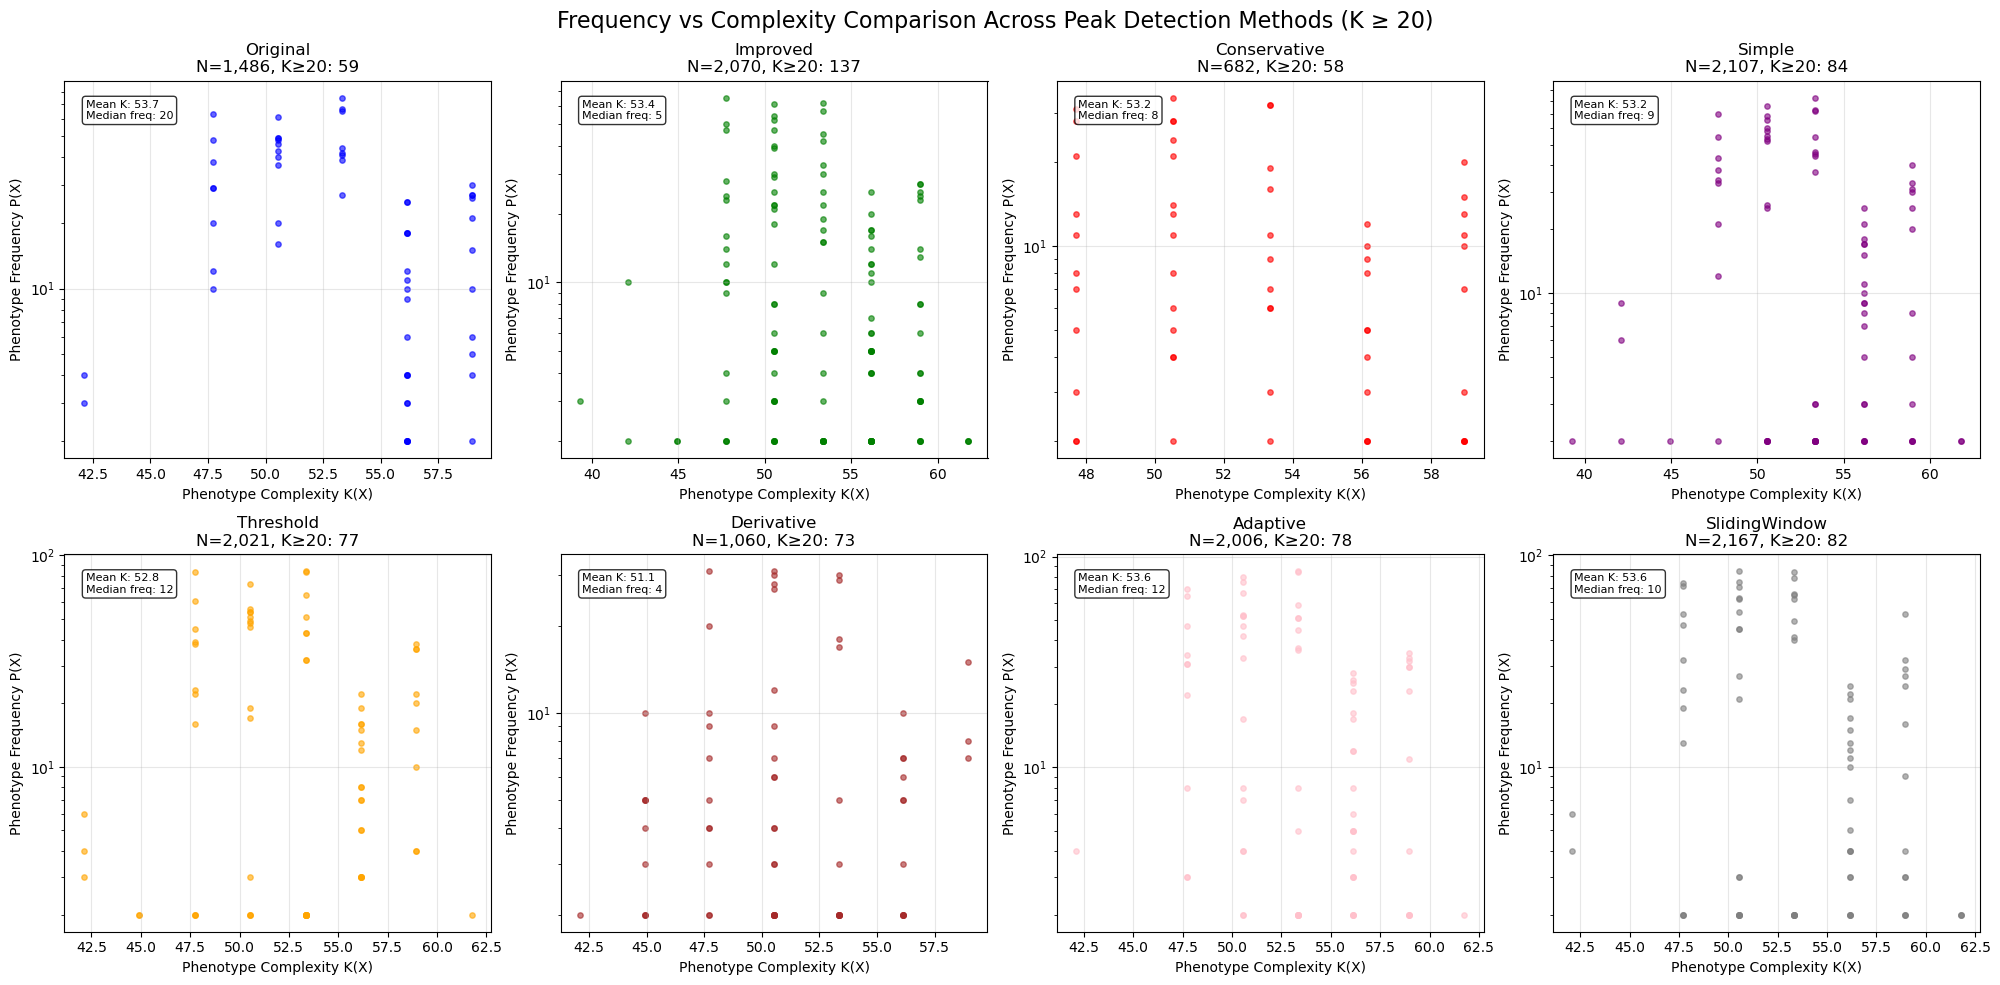

✅ Frequency-complexity comparison plots saved


In [76]:
# === FREQUENCY-COMPLEXITY COMPARISON PLOTS ===
print("\n📊 Creating frequency-complexity comparison plots...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()  # Make it easier to iterate
fig.suptitle('Frequency vs Complexity Comparison Across Peak Detection Methods (K ≥ 20)', fontsize=16)

colors = {
    'Original': 'blue', 
    'Improved': 'green', 
    'Conservative': 'red', 
    'Simple': 'purple',
    'Threshold': 'orange',
    'Derivative': 'brown',
    'Adaptive': 'pink',
    'SlidingWindow': 'gray'
}

for i, (method_name, results) in enumerate(all_results.items()):
    if results['success_count'] == 0:
        axes[i].text(0.5, 0.5, f'{method_name}\nNo successful\ndetections', 
                    ha='center', va='center', transform=axes[i].transAxes, fontsize=10)
        axes[i].set_title(f"{method_name} Method")
        continue
    
    # Calculate frequencies and filter K >= 20
    phenotype_counts = Counter(results['encodings'])
    phenotype_complexities = []
    phenotype_frequencies = []
    
    for phenotype, frequency in phenotype_counts.items():
        if frequency > 1:  # Skip single occurrences
            complexity = CLZ(phenotype)
            if complexity >= 20:  # Filter out K < 20
                phenotype_complexities.append(complexity)
                phenotype_frequencies.append(frequency)
    
    if phenotype_complexities:
        axes[i].scatter(phenotype_complexities, phenotype_frequencies, 
                       alpha=0.6, s=15, color=colors[method_name])
        axes[i].set_yscale('log')
        axes[i].set_xlabel('Phenotype Complexity K(X)')
        axes[i].set_ylabel('Phenotype Frequency P(X)')
        axes[i].set_title(f"{method_name}\nN={results['success_count']:,}, K≥20: {len(phenotype_complexities)}")
        axes[i].grid(True, alpha=0.3)
        
        # Add statistics
        mean_complex = np.mean(phenotype_complexities)
        median_freq = np.median(phenotype_frequencies)
        axes[i].text(0.05, 0.95, f'Mean K: {mean_complex:.1f}\nMedian freq: {median_freq:.0f}', 
                    transform=axes[i].transAxes, va='top', fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        axes[i].text(0.5, 0.5, f'{method_name}\nNo phenotypes\nwith K≥20', 
                    ha='center', va='center', transform=axes[i].transAxes, fontsize=10)

plt.tight_layout()
plt.savefig('comparison_plots/frequency_complexity_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Frequency-complexity comparison plots saved")

In [77]:
# === EXTREME COMPLEXITY ANALYSIS ===
print("\n🔍 Analyzing most and least complex oscillations...")

def find_extreme_complexities(results, method_name, n_examples=5):
    """Find examples of highest and lowest complexity oscillations"""
    if results['success_count'] == 0:
        return [], []
    
    complexities = np.array(results['complexities'])
    
    # Find indices of most and least complex
    sorted_indices = np.argsort(complexities)
    
    # Get n_examples from each end
    least_complex_indices = sorted_indices[:min(n_examples, len(sorted_indices))]
    most_complex_indices = sorted_indices[-min(n_examples, len(sorted_indices)):]
    
    least_complex_examples = []
    most_complex_examples = []
    
    for idx in least_complex_indices:
        least_complex_examples.append({
            'complexity': results['complexities'][idx],
            'period': results['periods'][idx],
            'encoding': results['encodings'][idx],
            'genotype': results['genotypes'][idx],
            'phenotype_data': results['phenotype_data'][idx]
        })
    
    for idx in most_complex_indices:
        most_complex_examples.append({
            'complexity': results['complexities'][idx],
            'period': results['periods'][idx],
            'encoding': results['encodings'][idx],
            'genotype': results['genotypes'][idx],
            'phenotype_data': results['phenotype_data'][idx]
        })
    
    return least_complex_examples, most_complex_examples

# Find extreme examples for each method
extreme_examples = {}
for method_name, results in all_results.items():
    least, most = find_extreme_complexities(results, method_name, N_EXAMPLES_PER_METHOD)
    extreme_examples[method_name] = {'least': least, 'most': most}
    
    if results['success_count'] > 0:
        print(f"\n{method_name} Method:")
        if least:
            print(f"  Least complex: {least[0]['complexity']:.2f} (period: {least[0]['period']:.1f} min)")
        if most:
            print(f"  Most complex: {most[-1]['complexity']:.2f} (period: {most[-1]['period']:.1f} min)")
        
        complexities = results['complexities']
        print(f"  Complexity range: {min(complexities):.2f} - {max(complexities):.2f}")
        print(f"  Standard deviation: {np.std(complexities):.2f}")

print("\n✅ Extreme complexity analysis completed")


🔍 Analyzing most and least complex oscillations...

Original Method:
  Least complex: 42.11 (period: 232.0 min)
  Most complex: 61.76 (period: 177.0 min)
  Complexity range: 42.11 - 61.76
  Standard deviation: 3.61

Improved Method:
  Least complex: 5.61 (period: 200.2 min)
  Most complex: 67.38 (period: 186.8 min)
  Complexity range: 5.61 - 67.38
  Standard deviation: 5.24

Conservative Method:
  Least complex: 42.11 (period: 167.0 min)
  Most complex: 64.57 (period: 151.2 min)
  Complexity range: 42.11 - 64.57
  Standard deviation: 3.76

Simple Method:
  Least complex: 39.30 (period: 154.7 min)
  Most complex: 61.76 (period: 62.0 min)
  Complexity range: 39.30 - 61.76
  Standard deviation: 3.67

Threshold Method:
  Least complex: 42.11 (period: 201.5 min)
  Most complex: 64.57 (period: 236.0 min)
  Complexity range: 42.11 - 64.57
  Standard deviation: 3.69

Derivative Method:
  Least complex: 42.11 (period: 290.5 min)
  Most complex: 67.38 (period: 197.5 min)
  Complexity range: 42.


🎨 Creating visualizations of extreme complexity examples...

Creating plots for Original method...


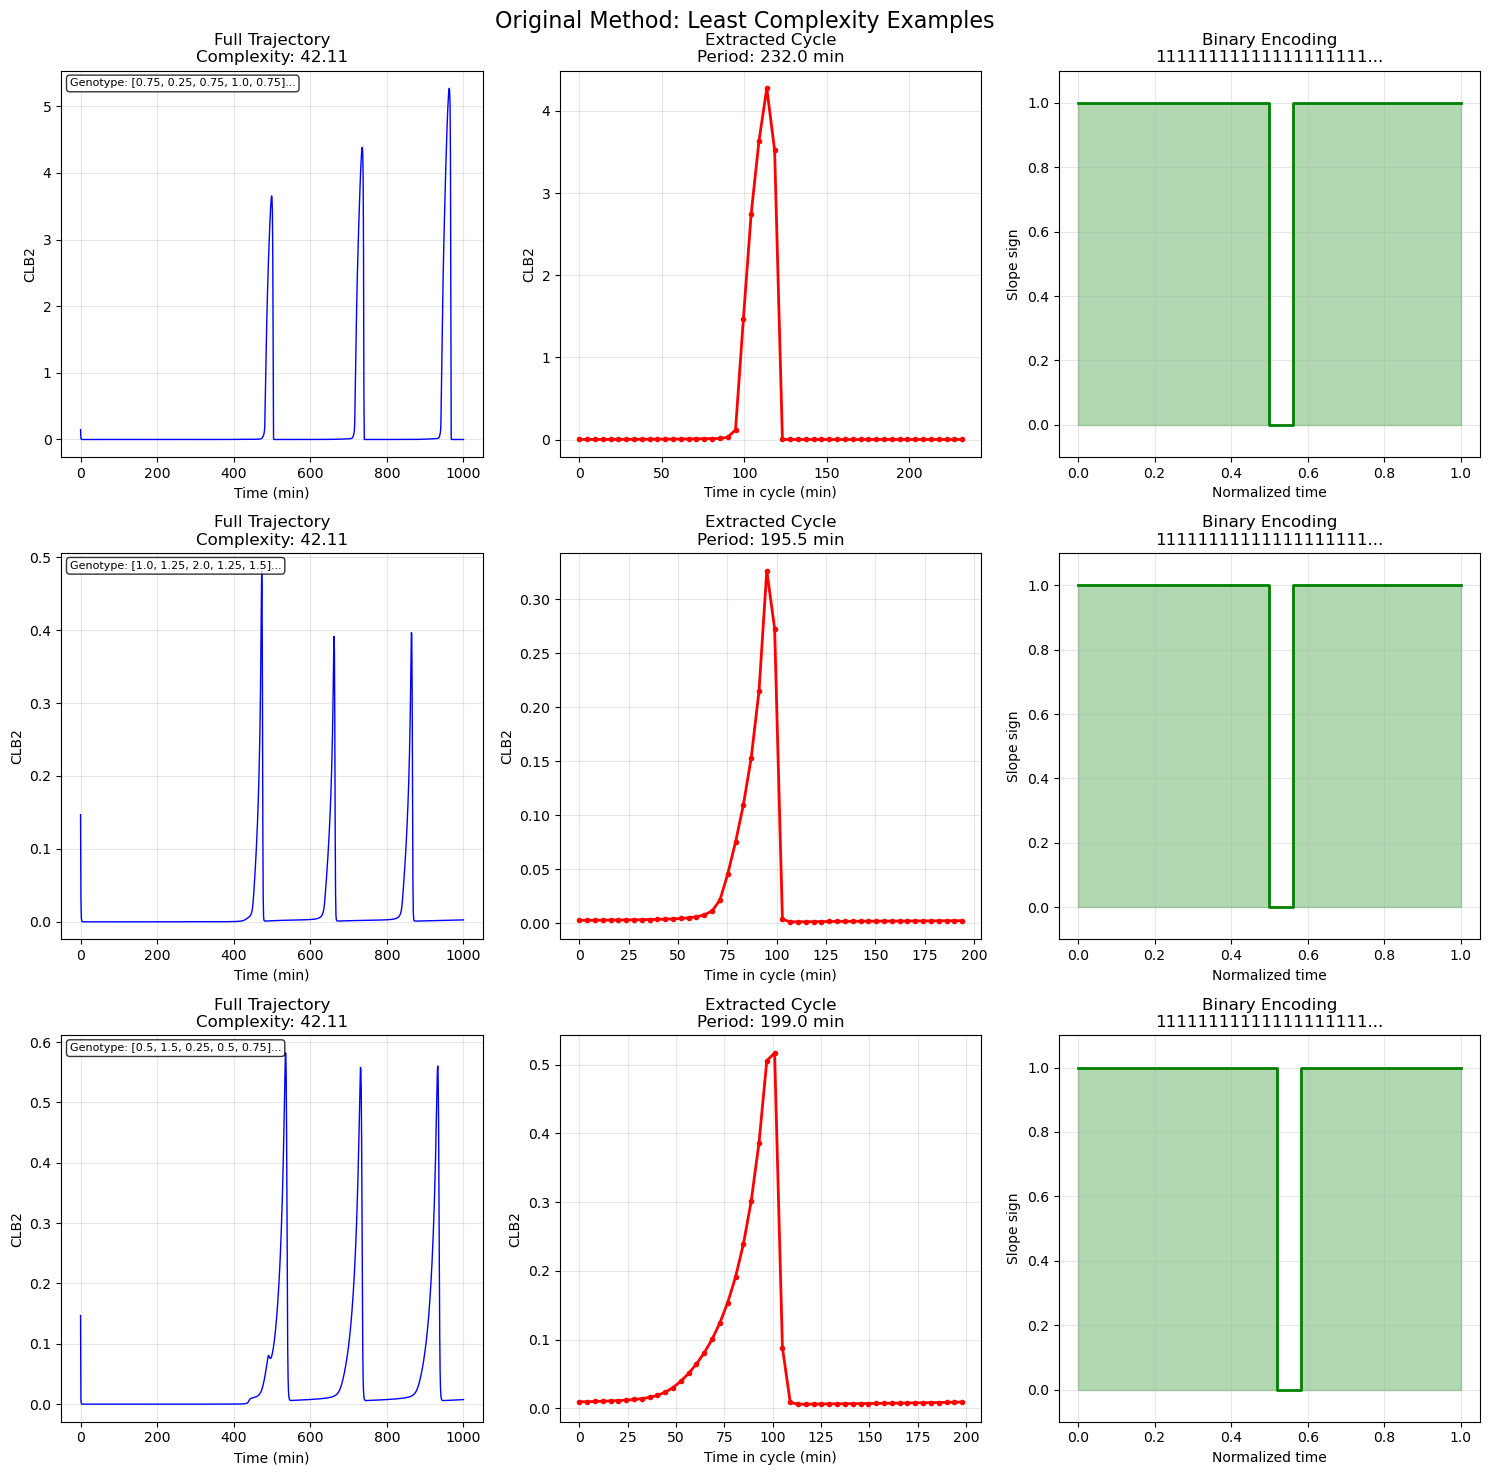

  Saved: comparison_plots/original_least_complexity_examples.png


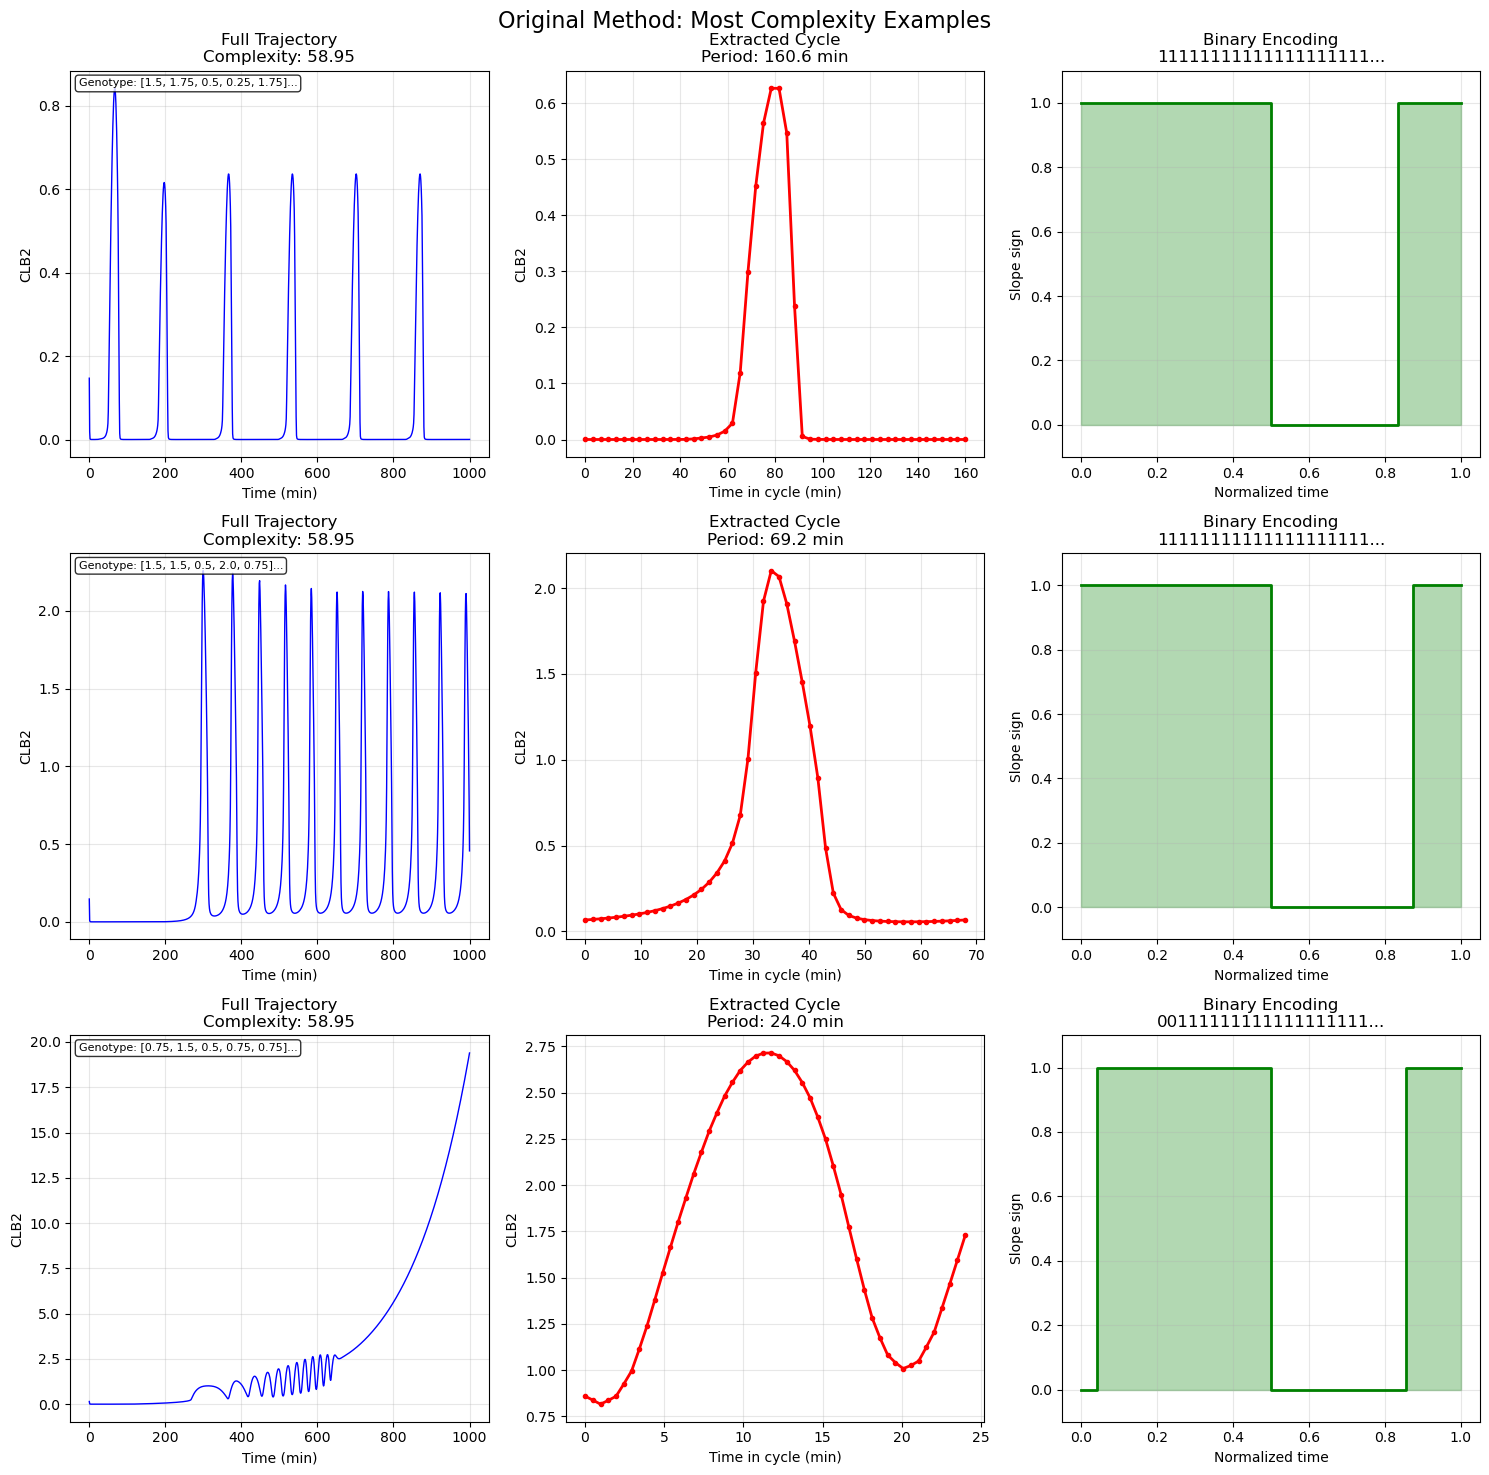

  Saved: comparison_plots/original_most_complexity_examples.png

Creating plots for Improved method...


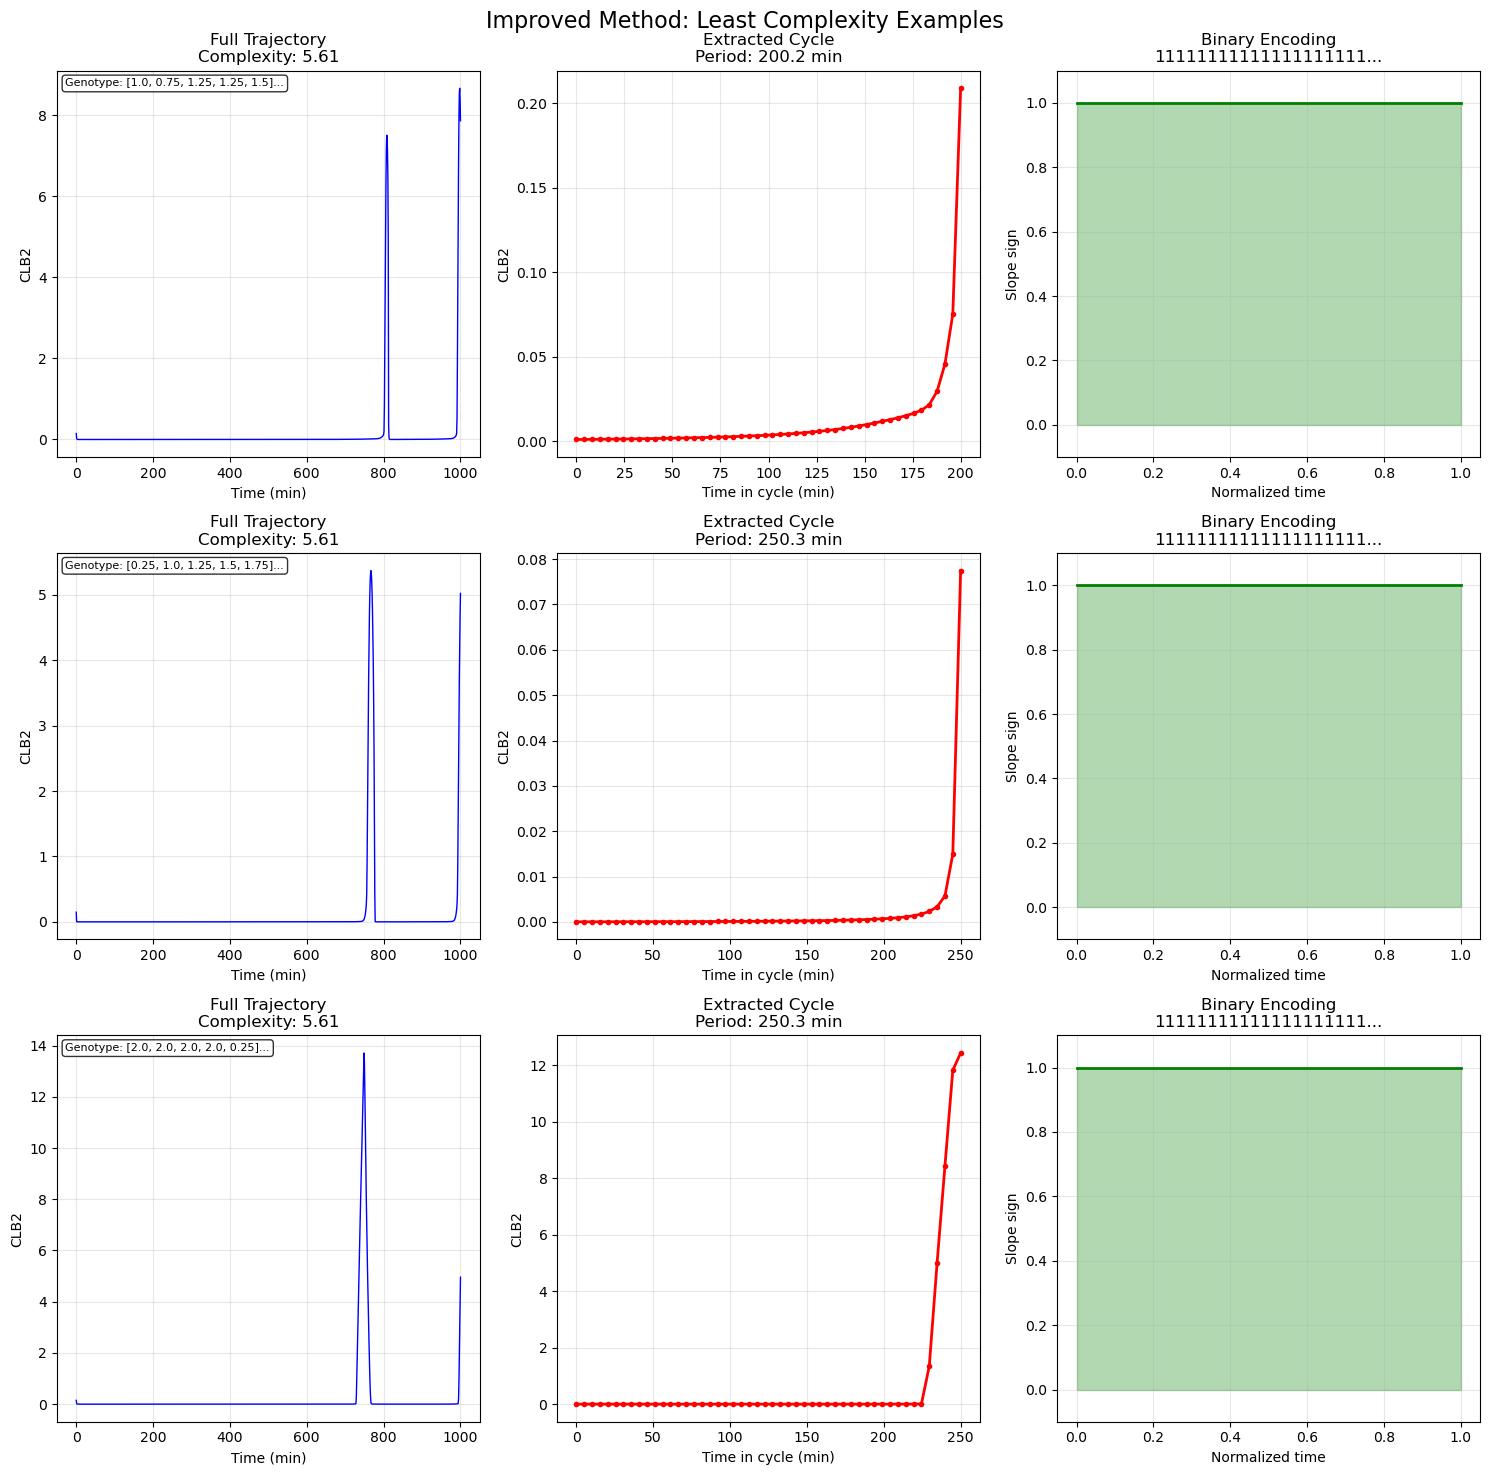

  Saved: comparison_plots/improved_least_complexity_examples.png


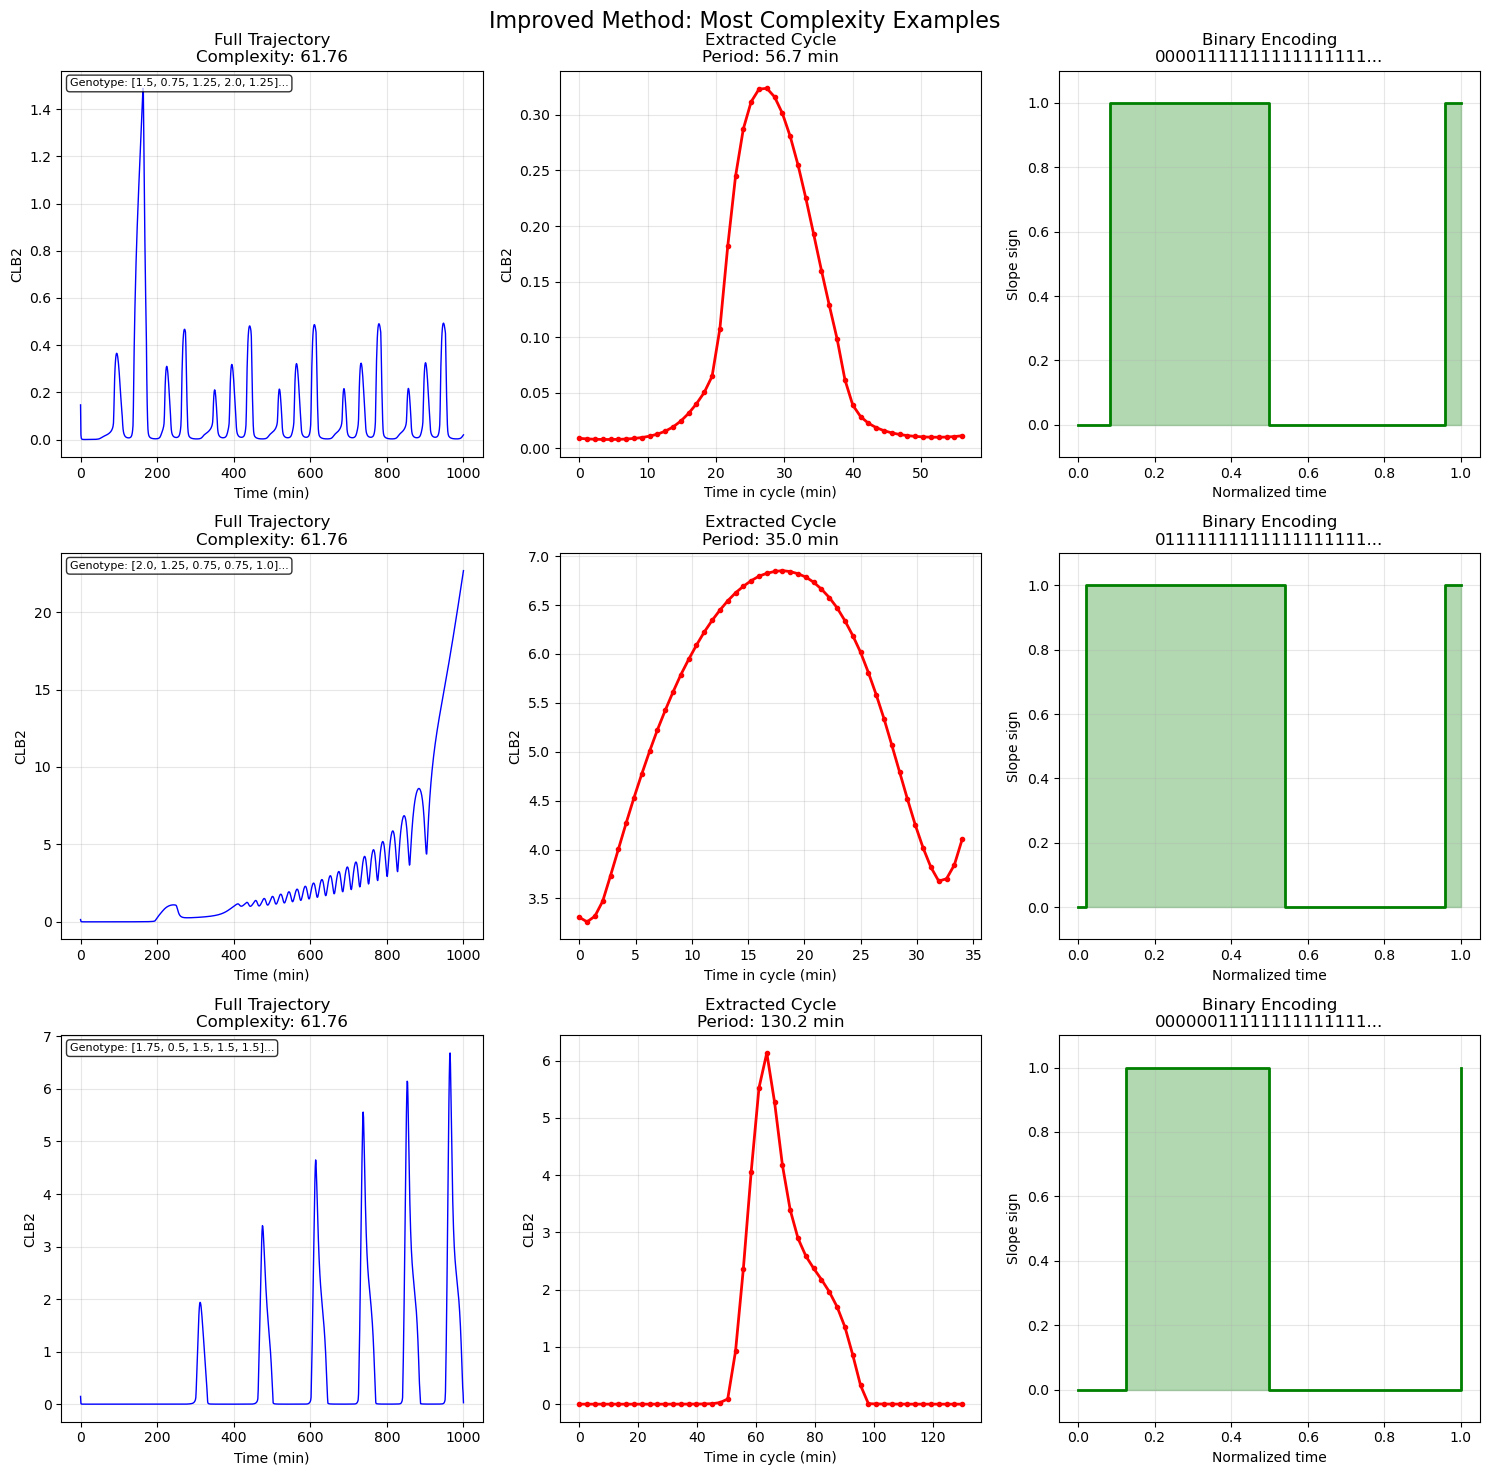

  Saved: comparison_plots/improved_most_complexity_examples.png

Creating plots for Conservative method...


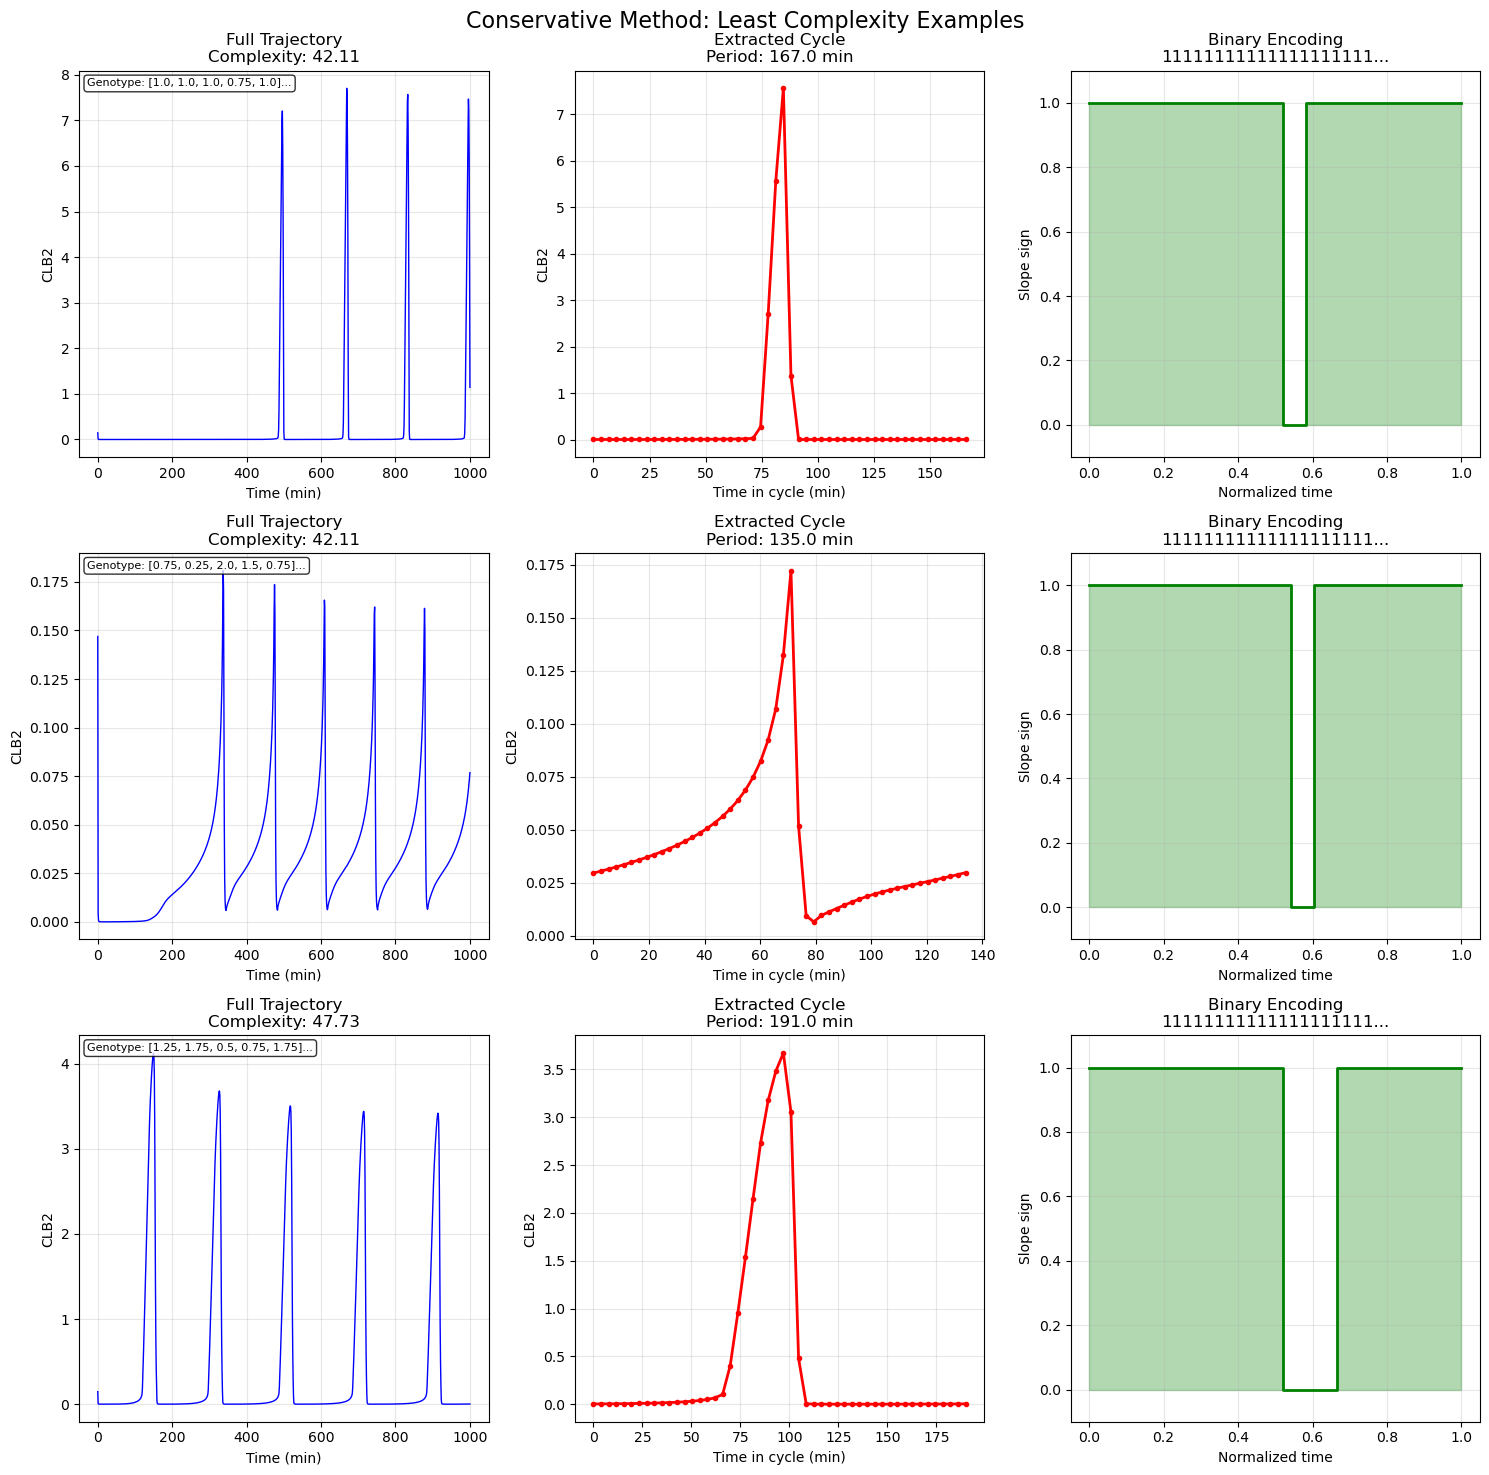

  Saved: comparison_plots/conservative_least_complexity_examples.png


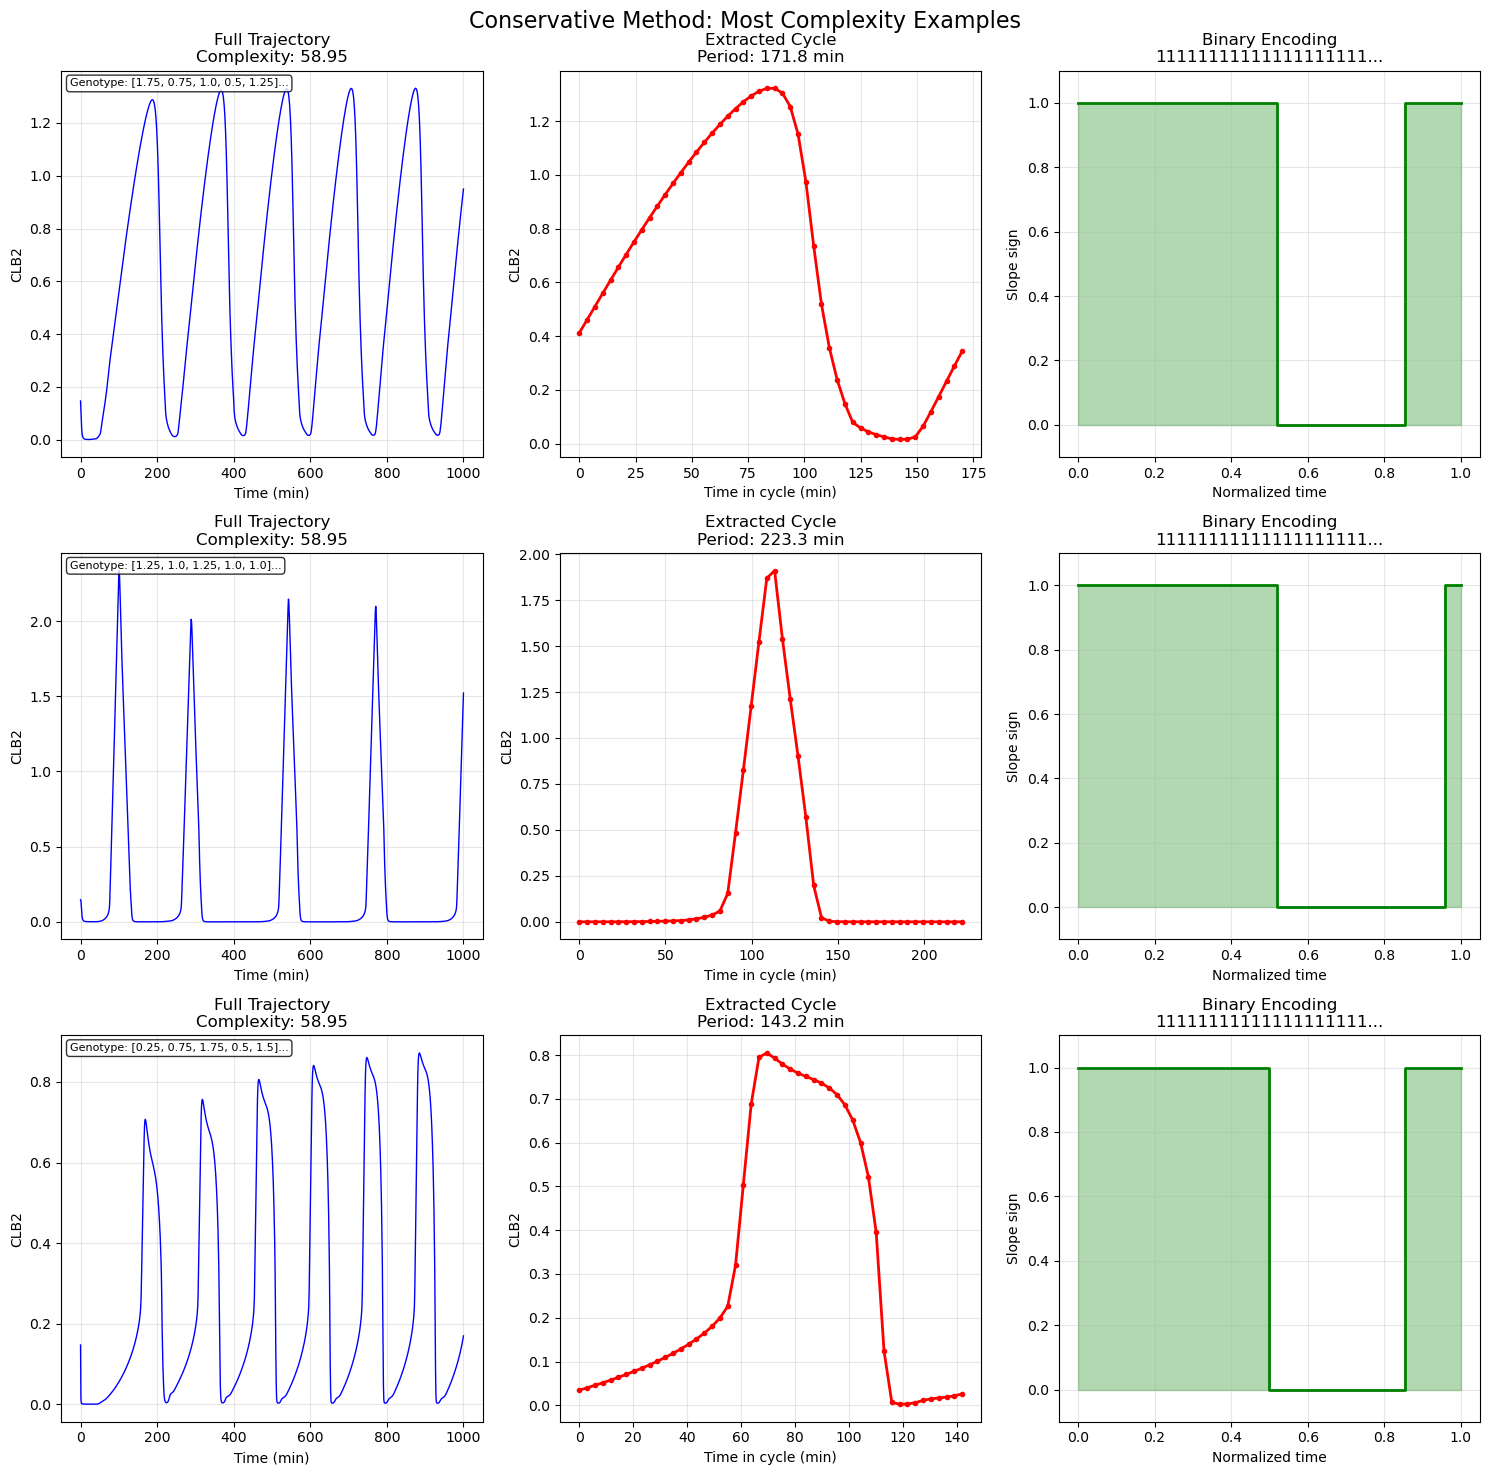

  Saved: comparison_plots/conservative_most_complexity_examples.png

Creating plots for Simple method...


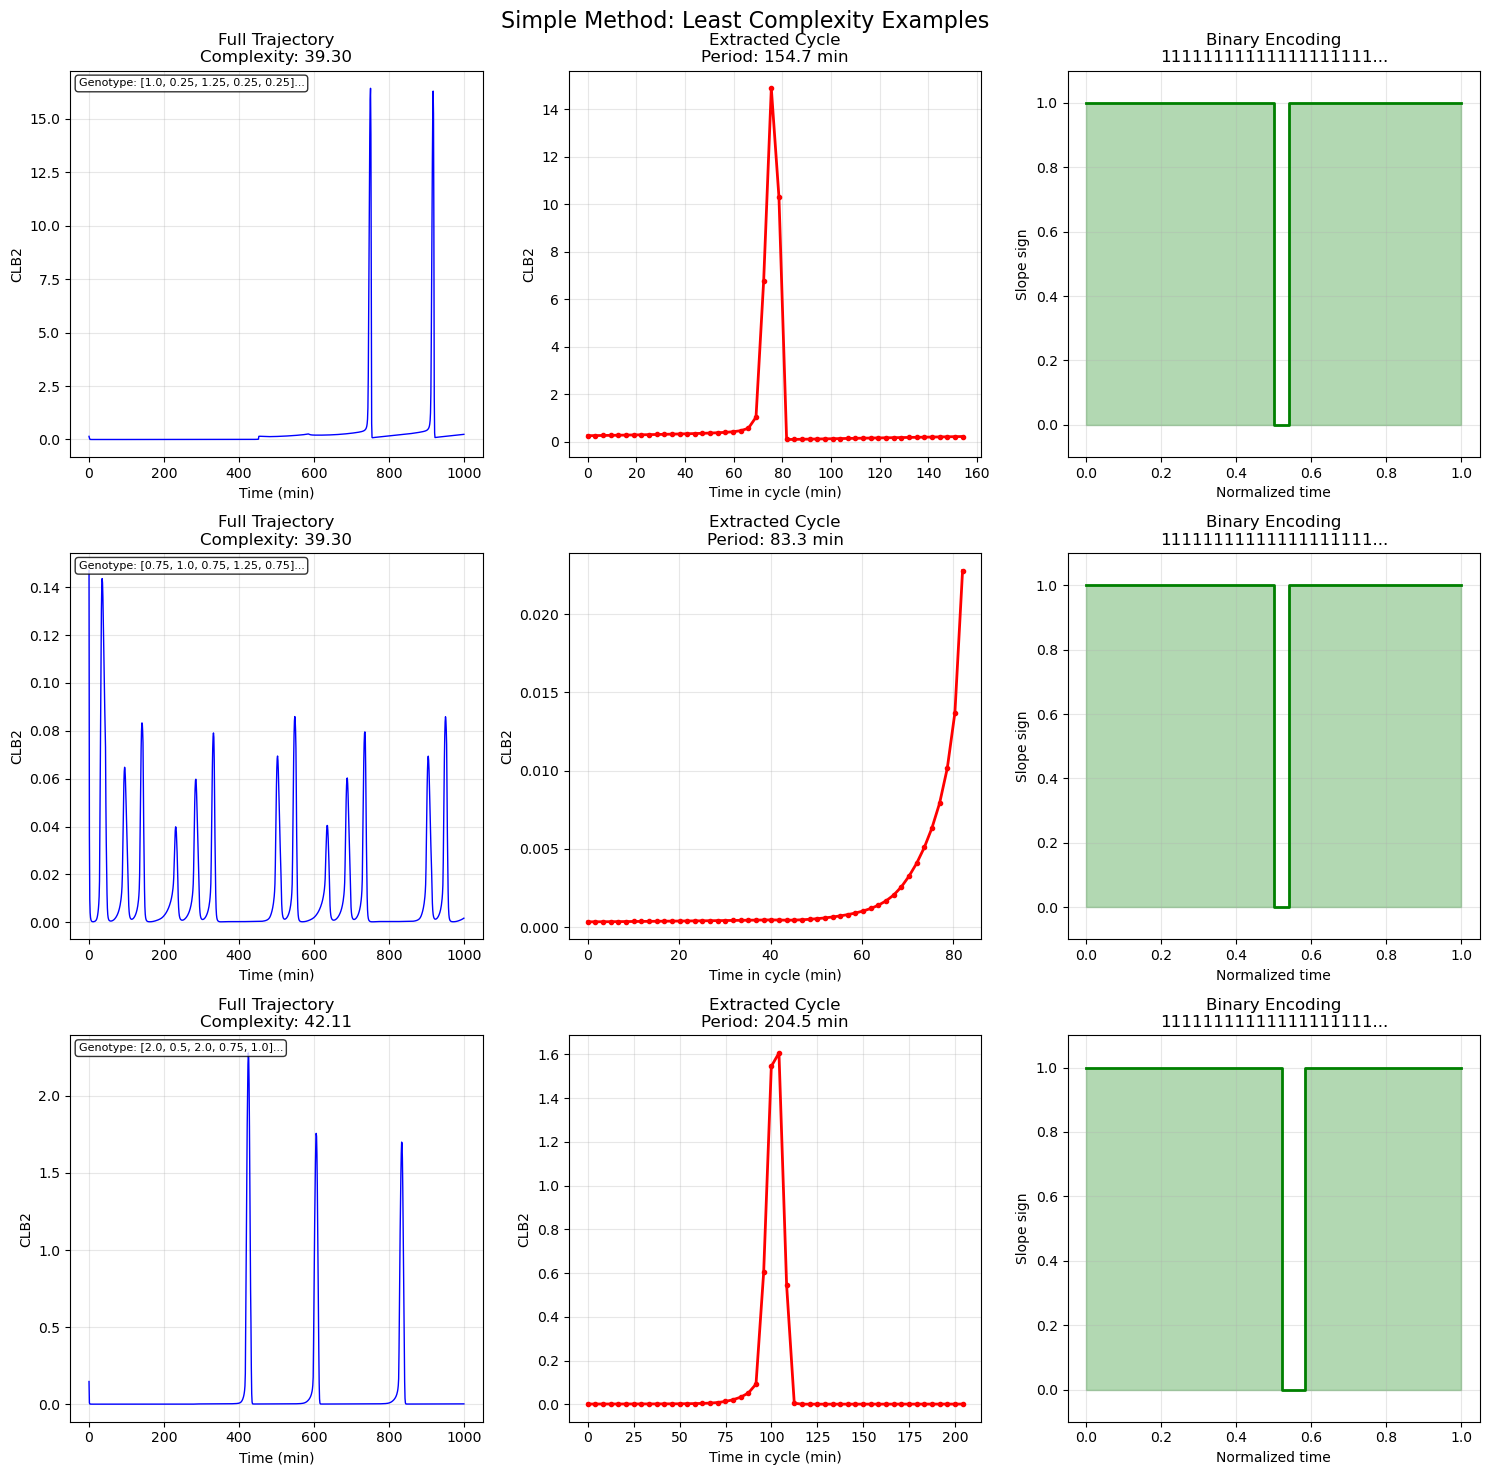

  Saved: comparison_plots/simple_least_complexity_examples.png


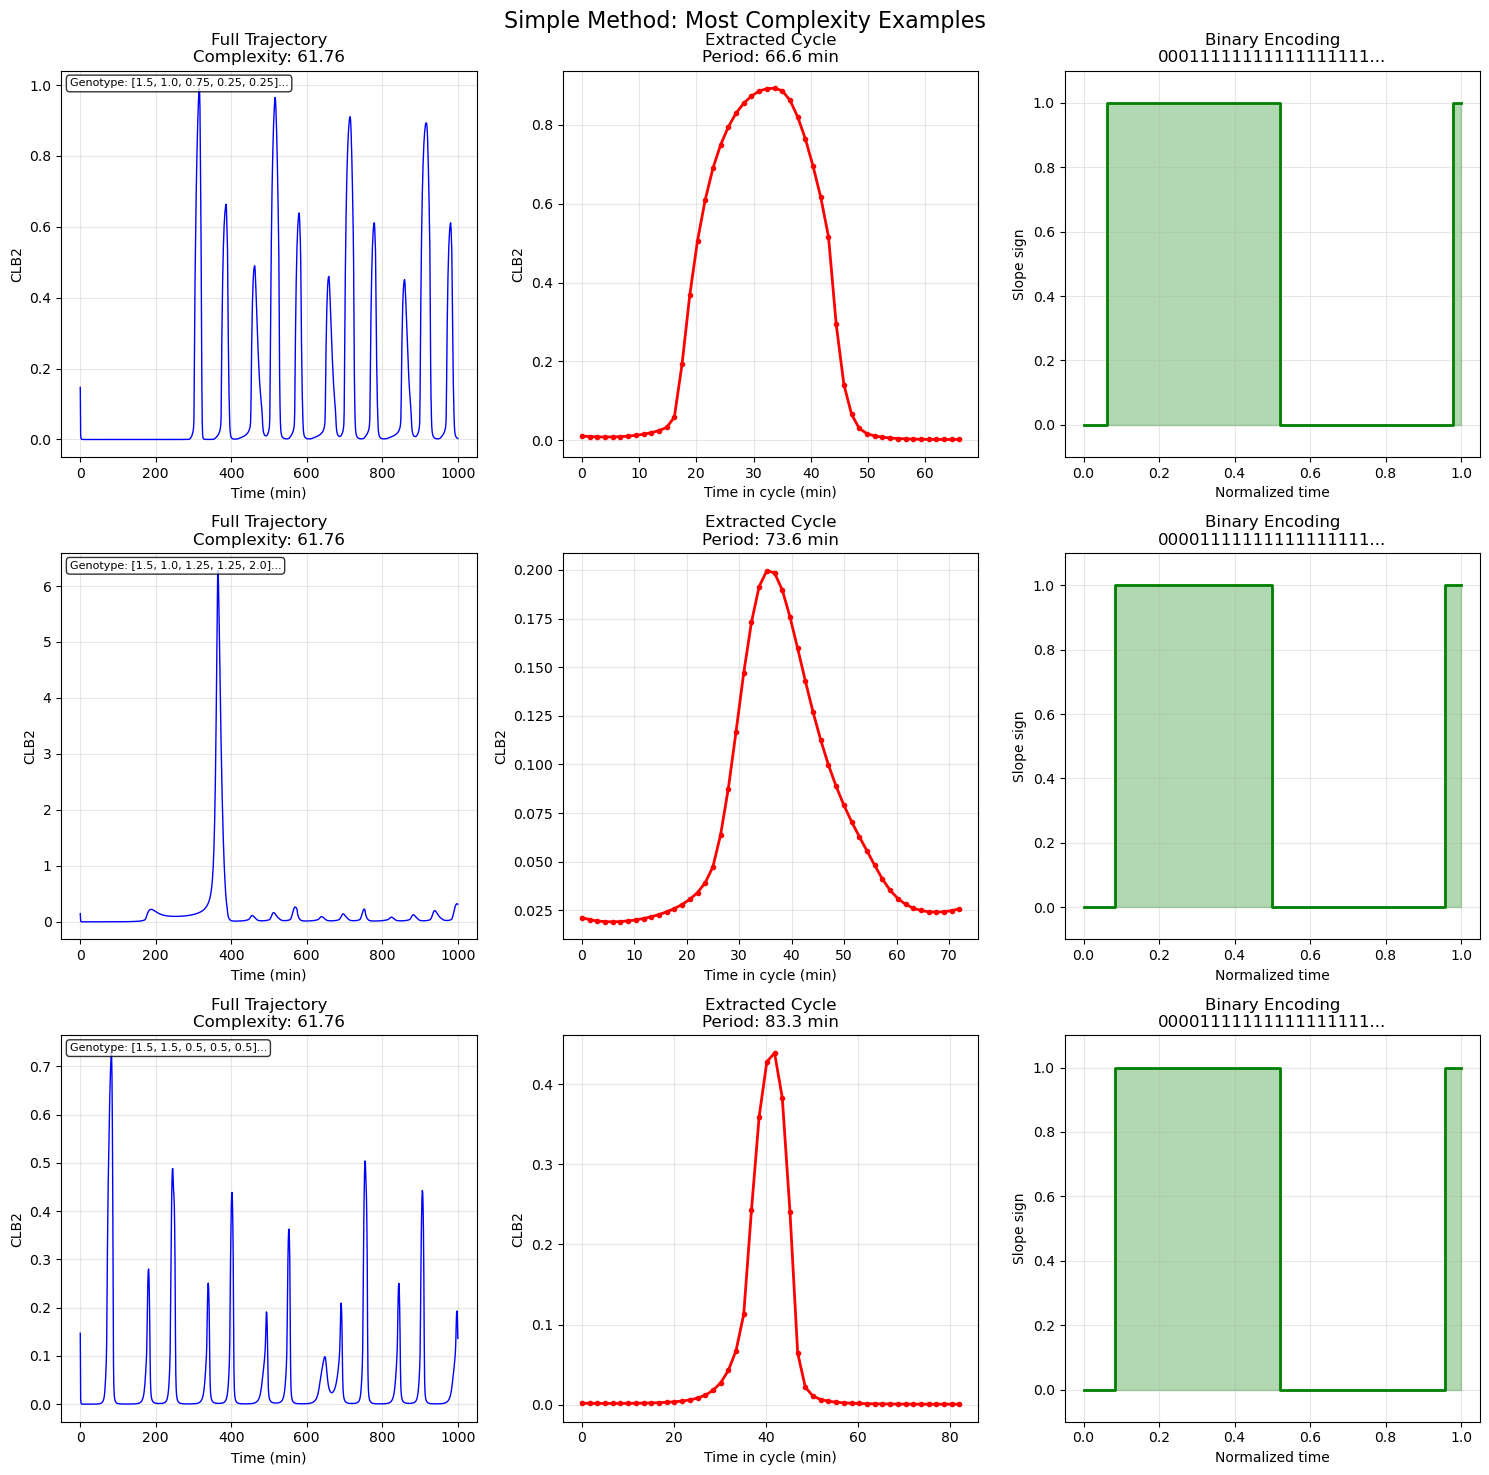

  Saved: comparison_plots/simple_most_complexity_examples.png

Creating plots for Threshold method...


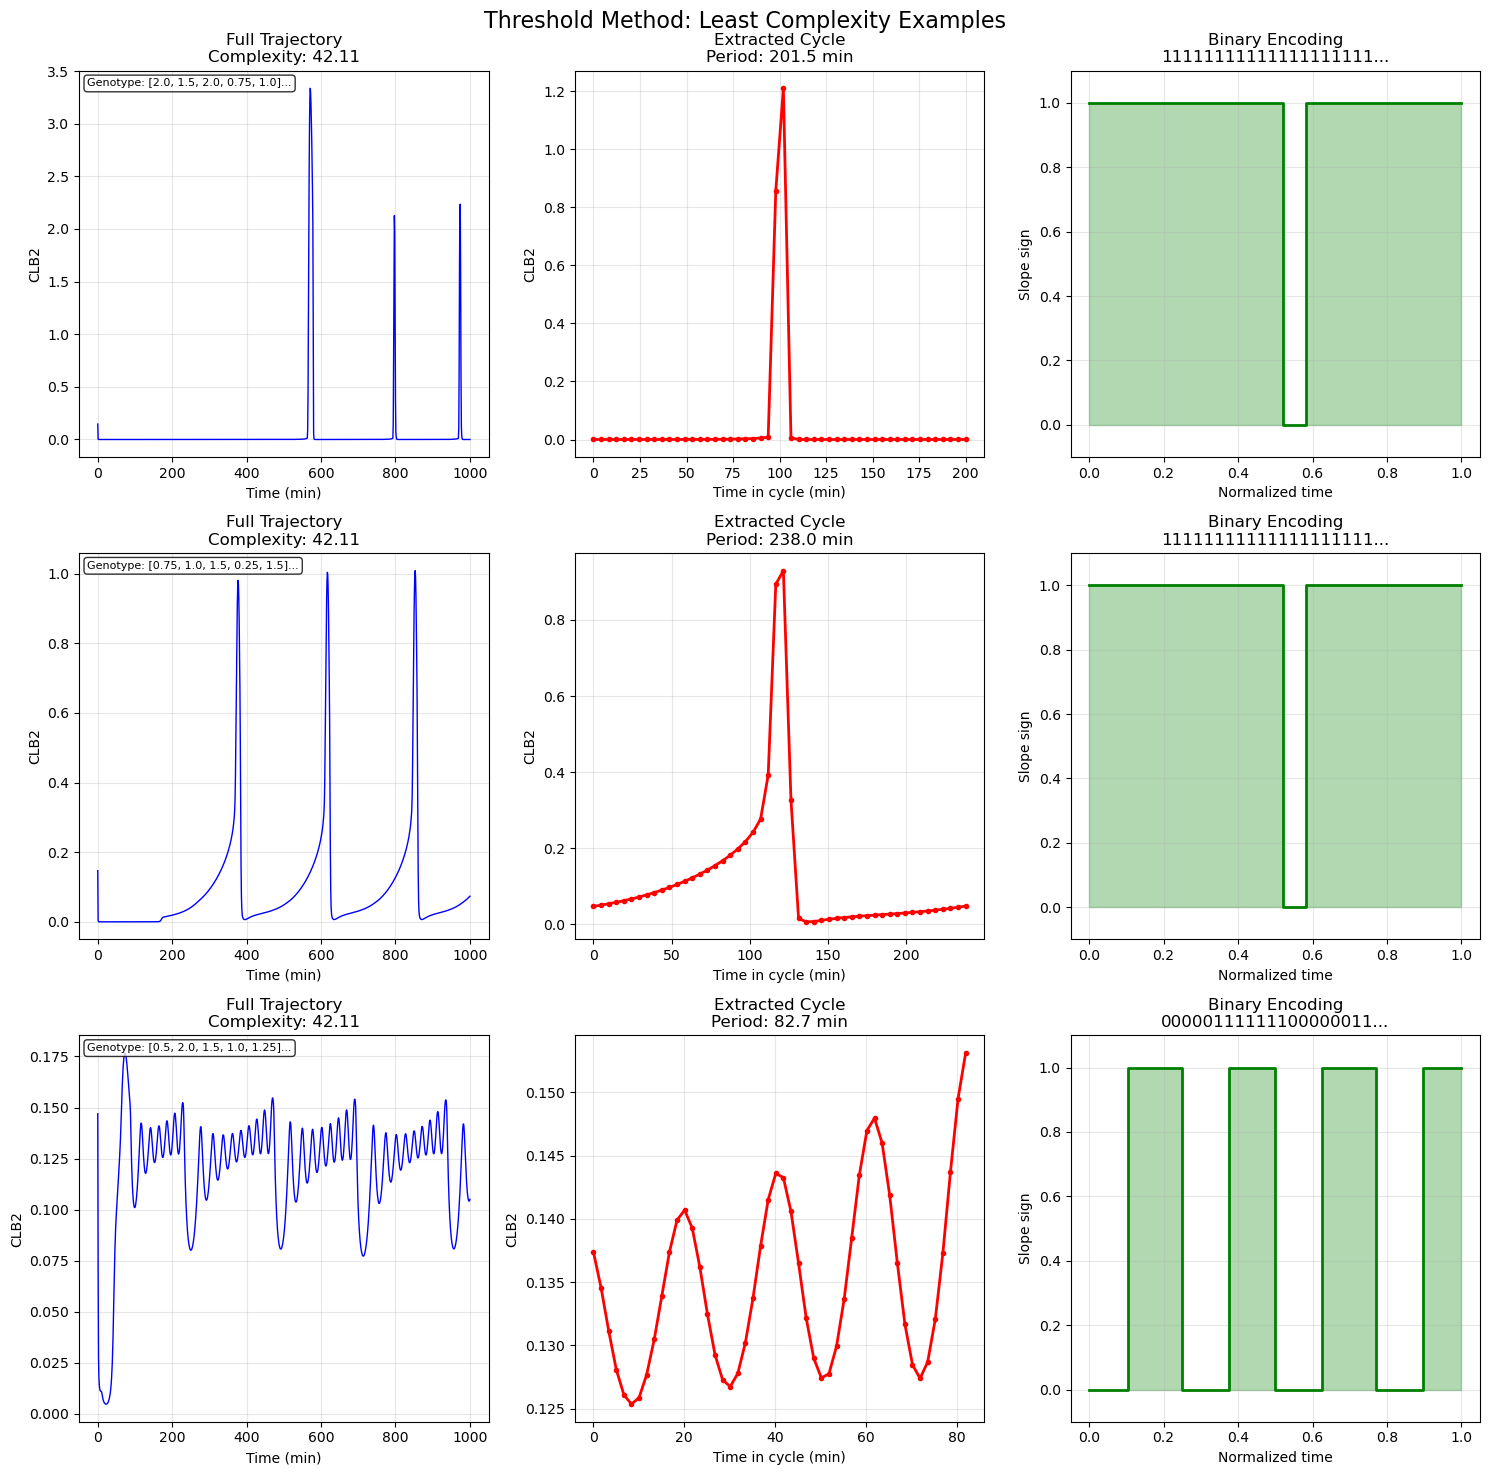

  Saved: comparison_plots/threshold_least_complexity_examples.png


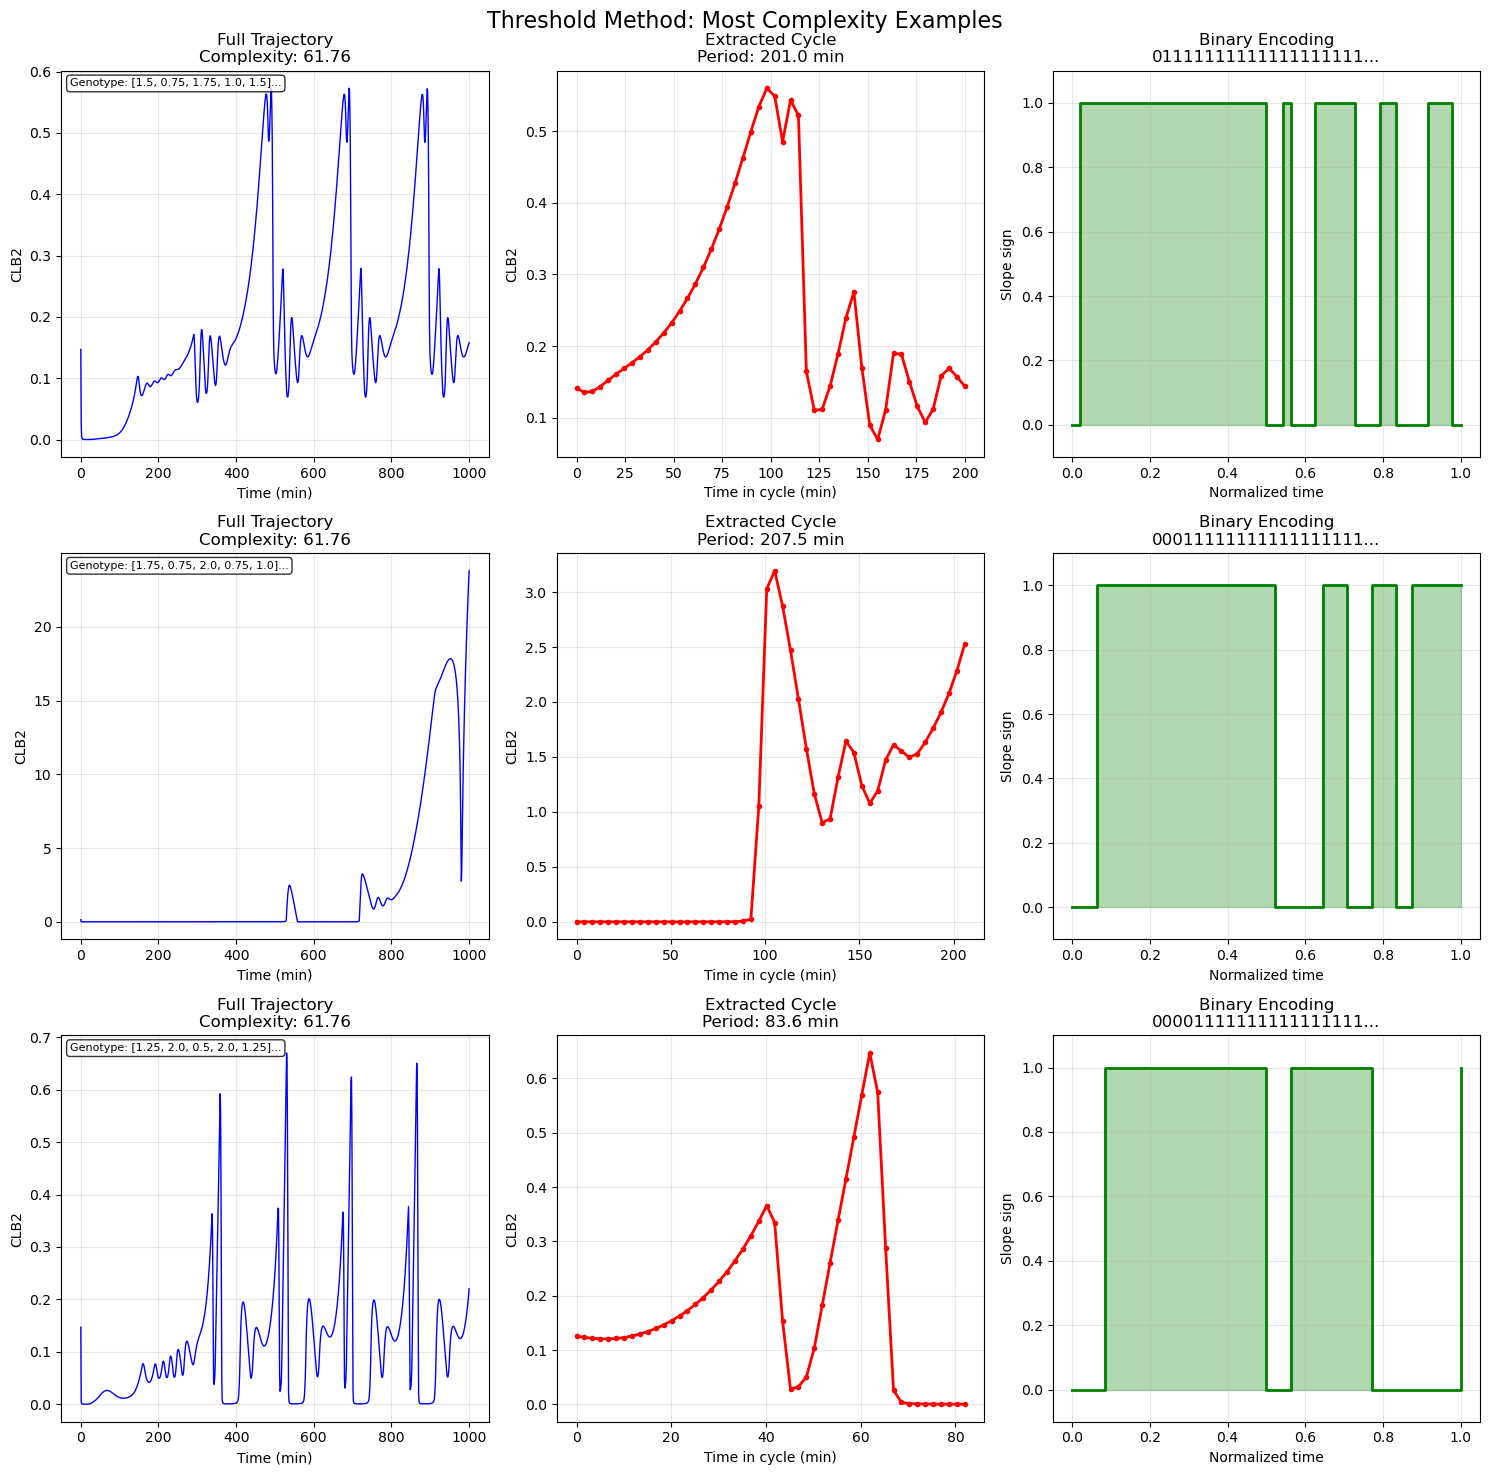

  Saved: comparison_plots/threshold_most_complexity_examples.png

Creating plots for Derivative method...


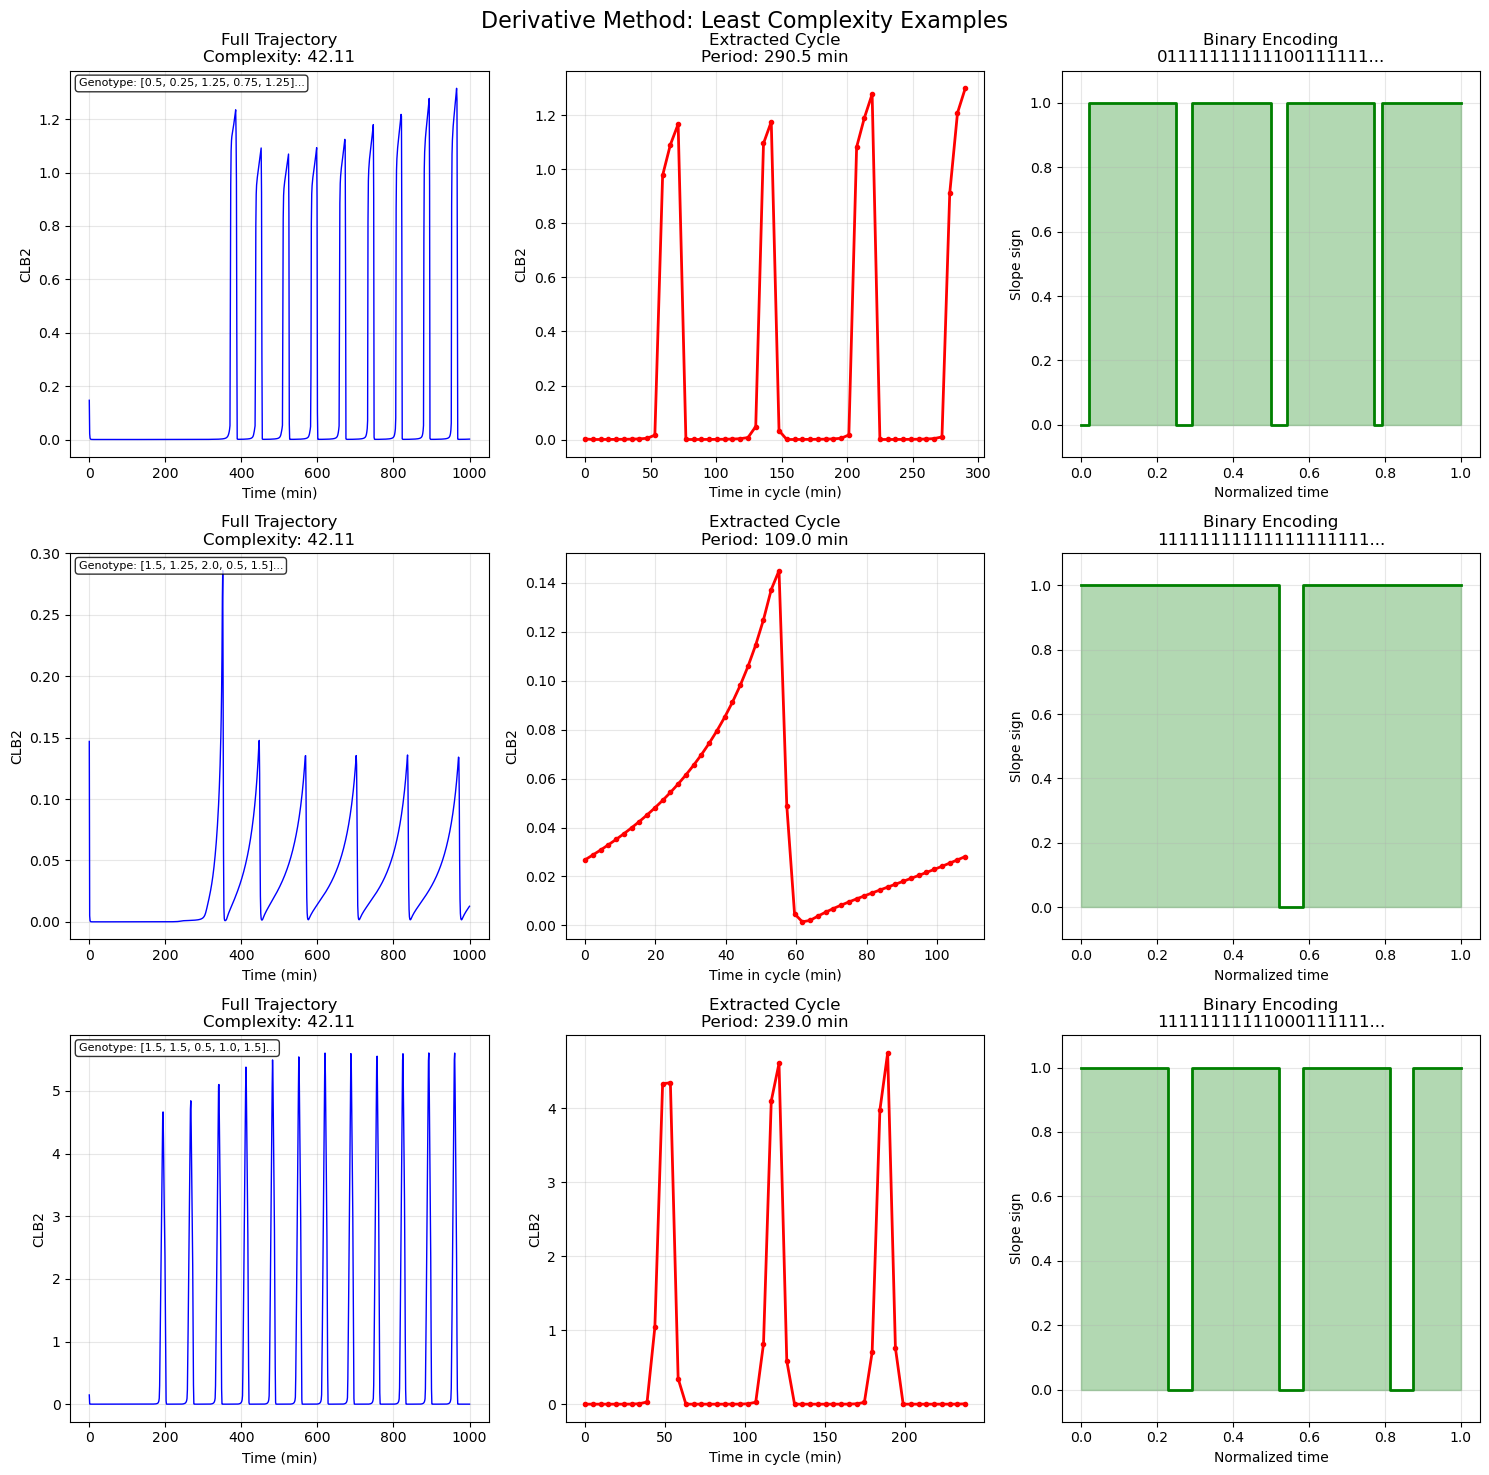

  Saved: comparison_plots/derivative_least_complexity_examples.png


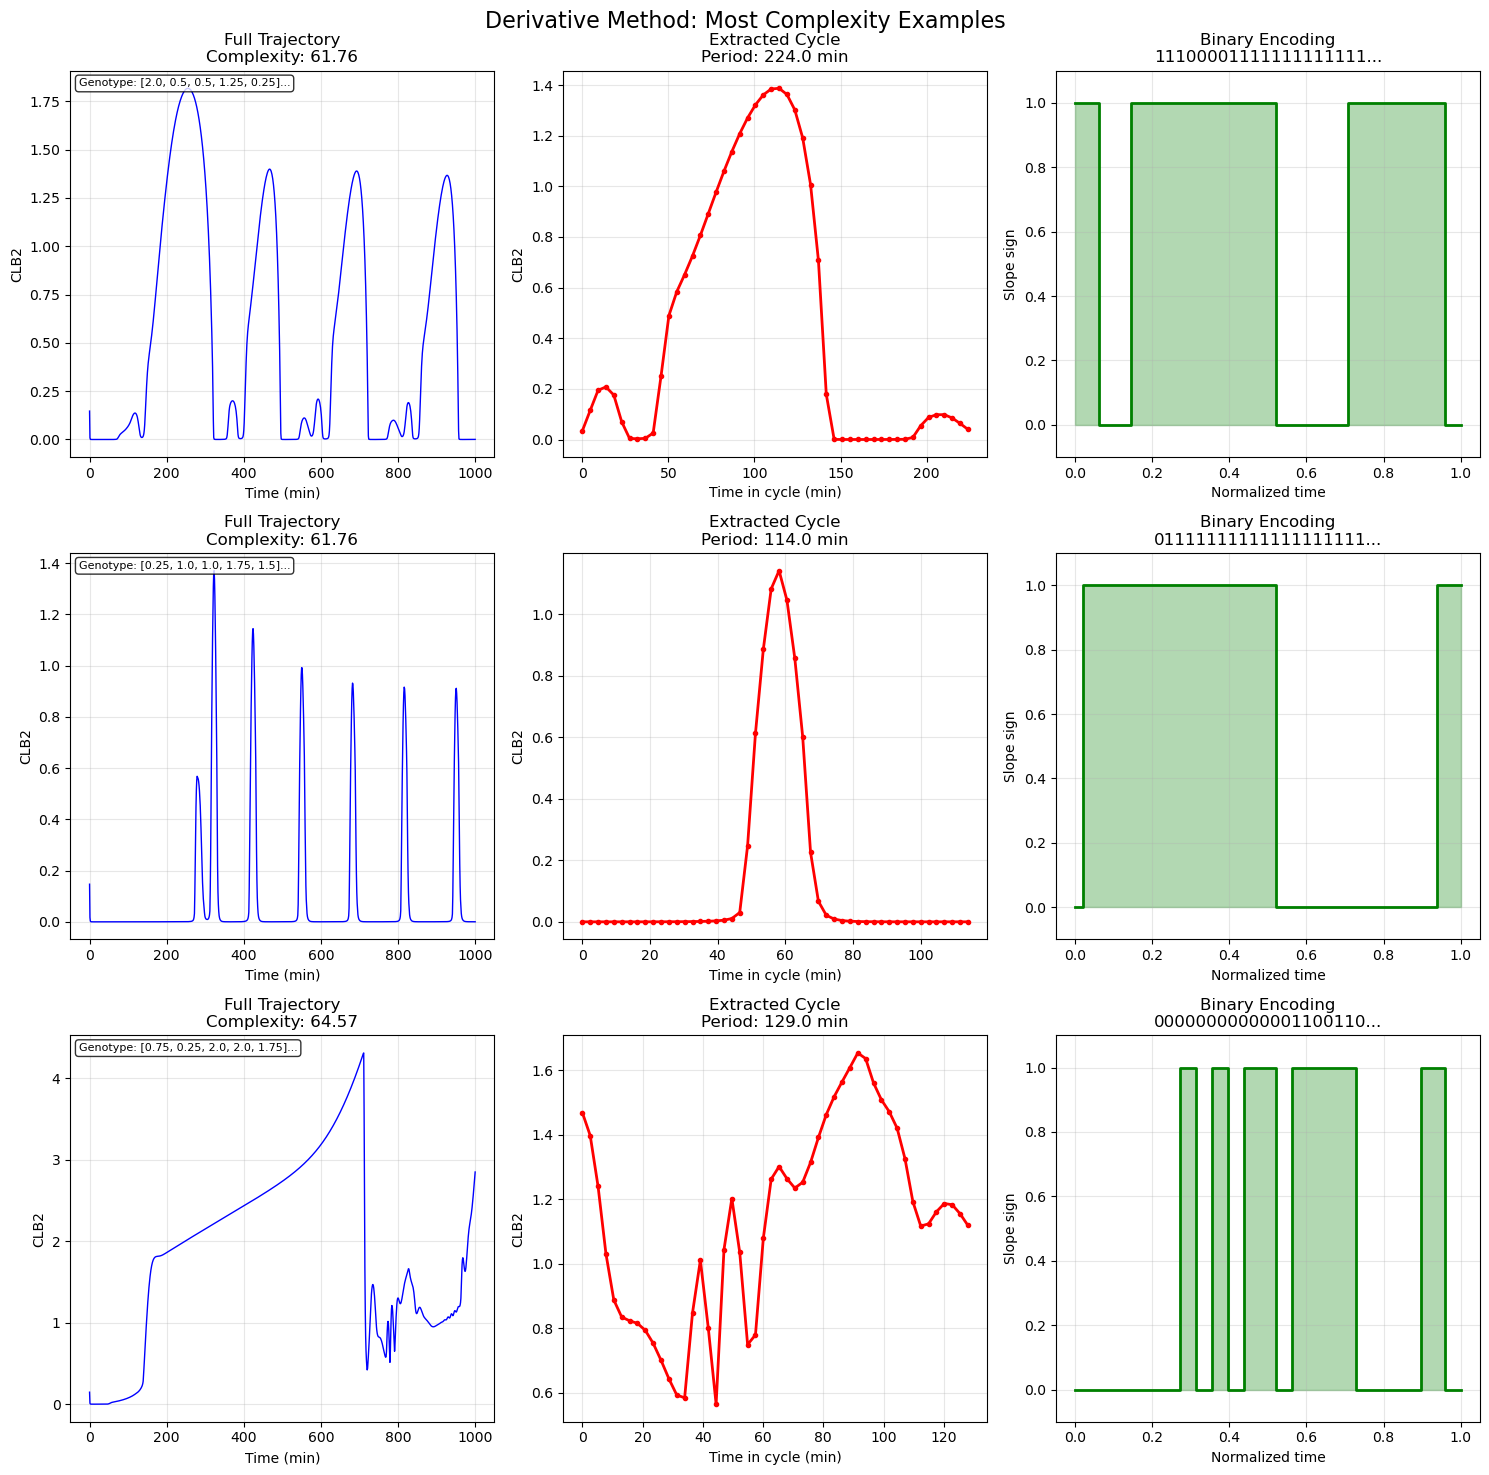

  Saved: comparison_plots/derivative_most_complexity_examples.png

Creating plots for Adaptive method...


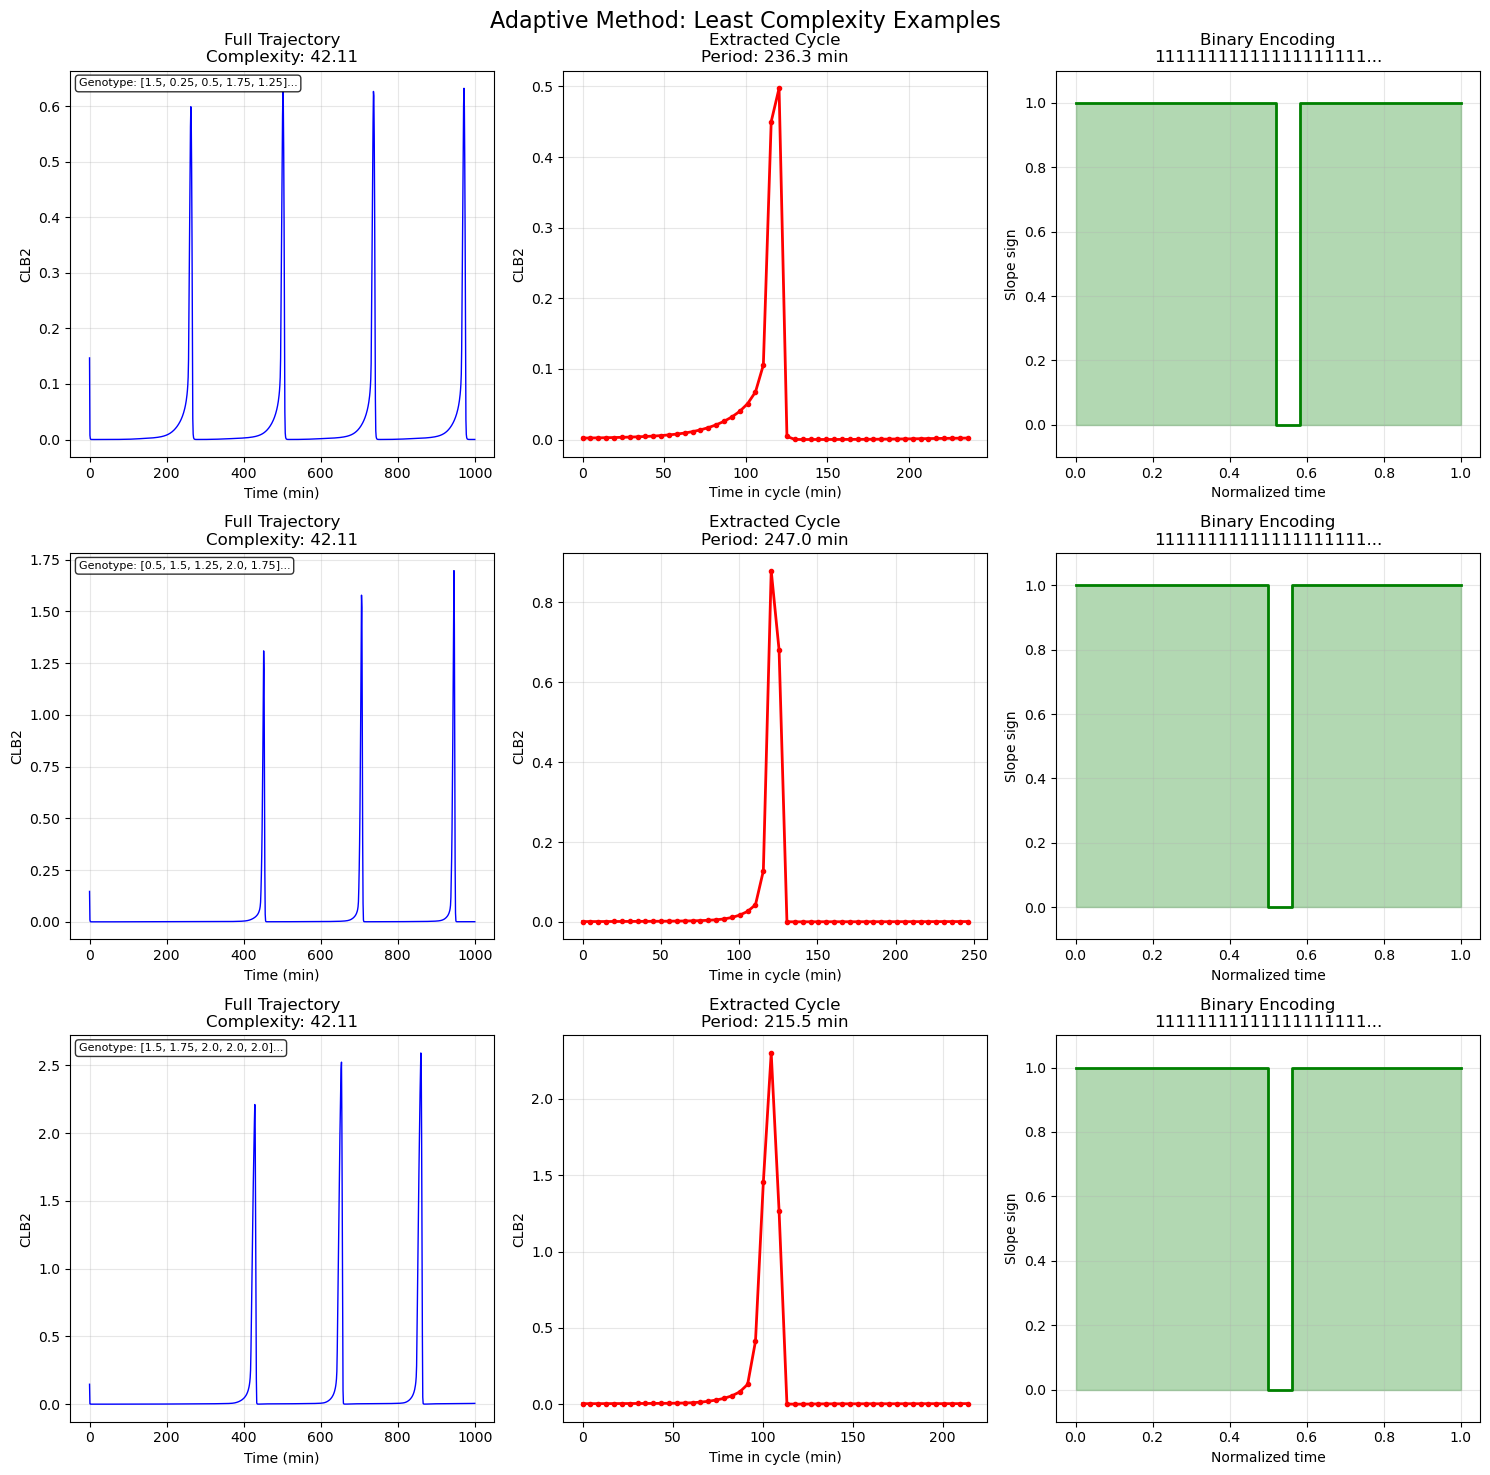

  Saved: comparison_plots/adaptive_least_complexity_examples.png


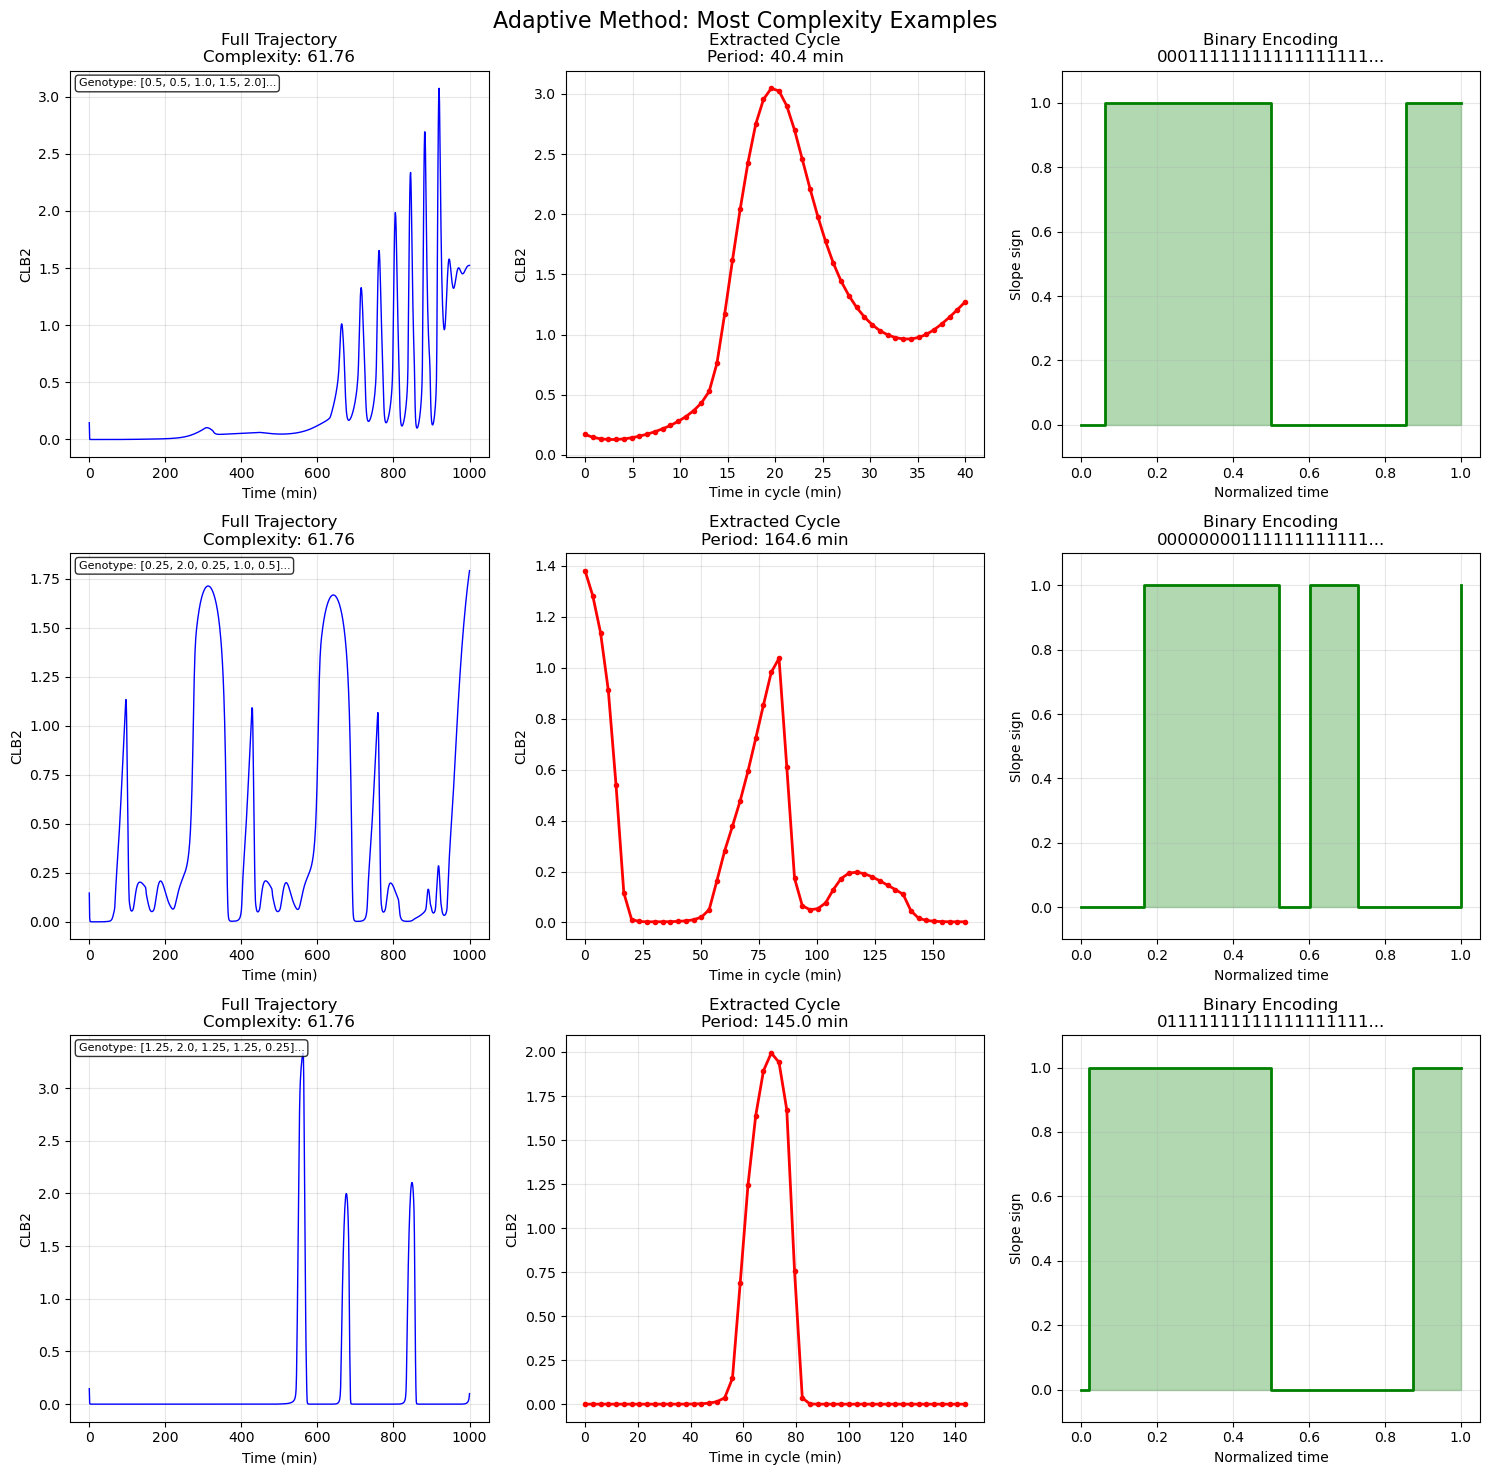

  Saved: comparison_plots/adaptive_most_complexity_examples.png

Creating plots for SlidingWindow method...


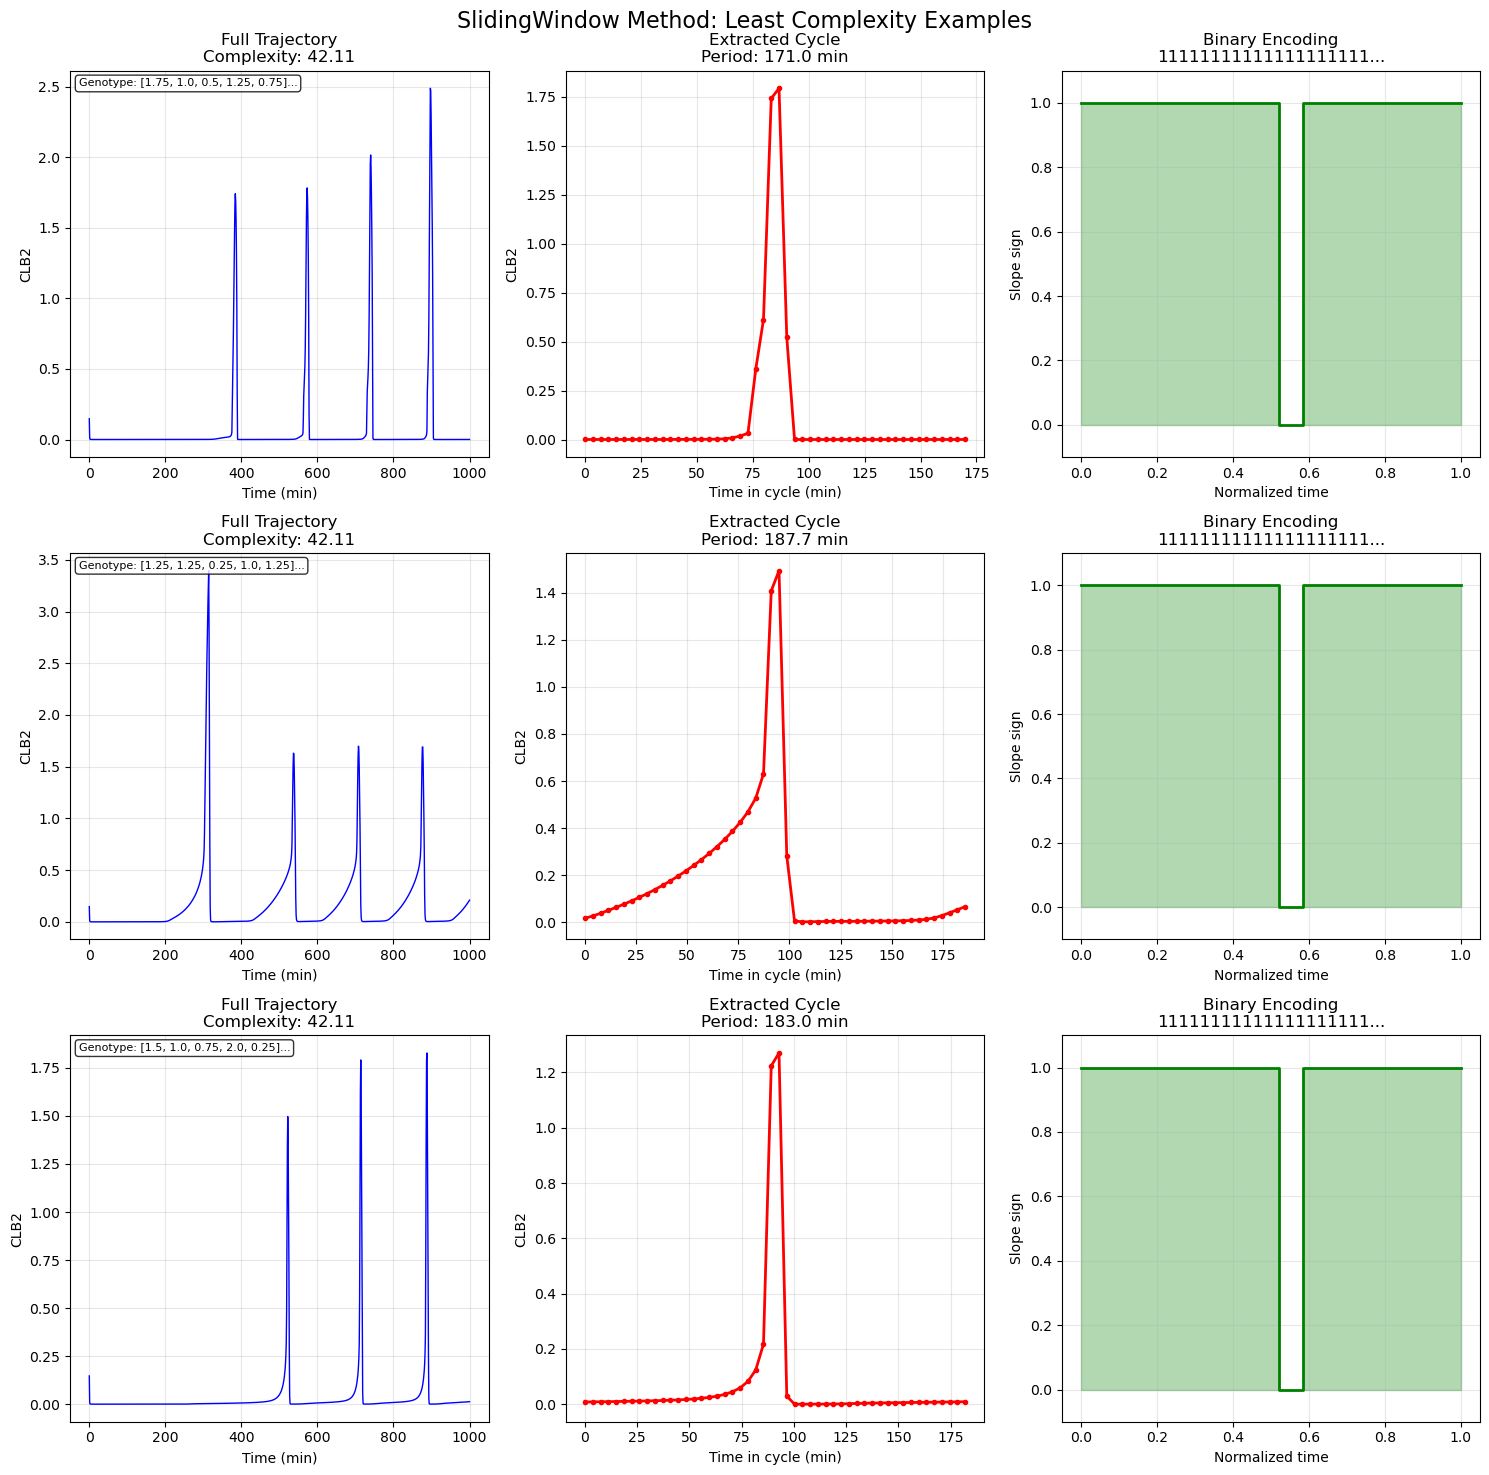

  Saved: comparison_plots/slidingwindow_least_complexity_examples.png


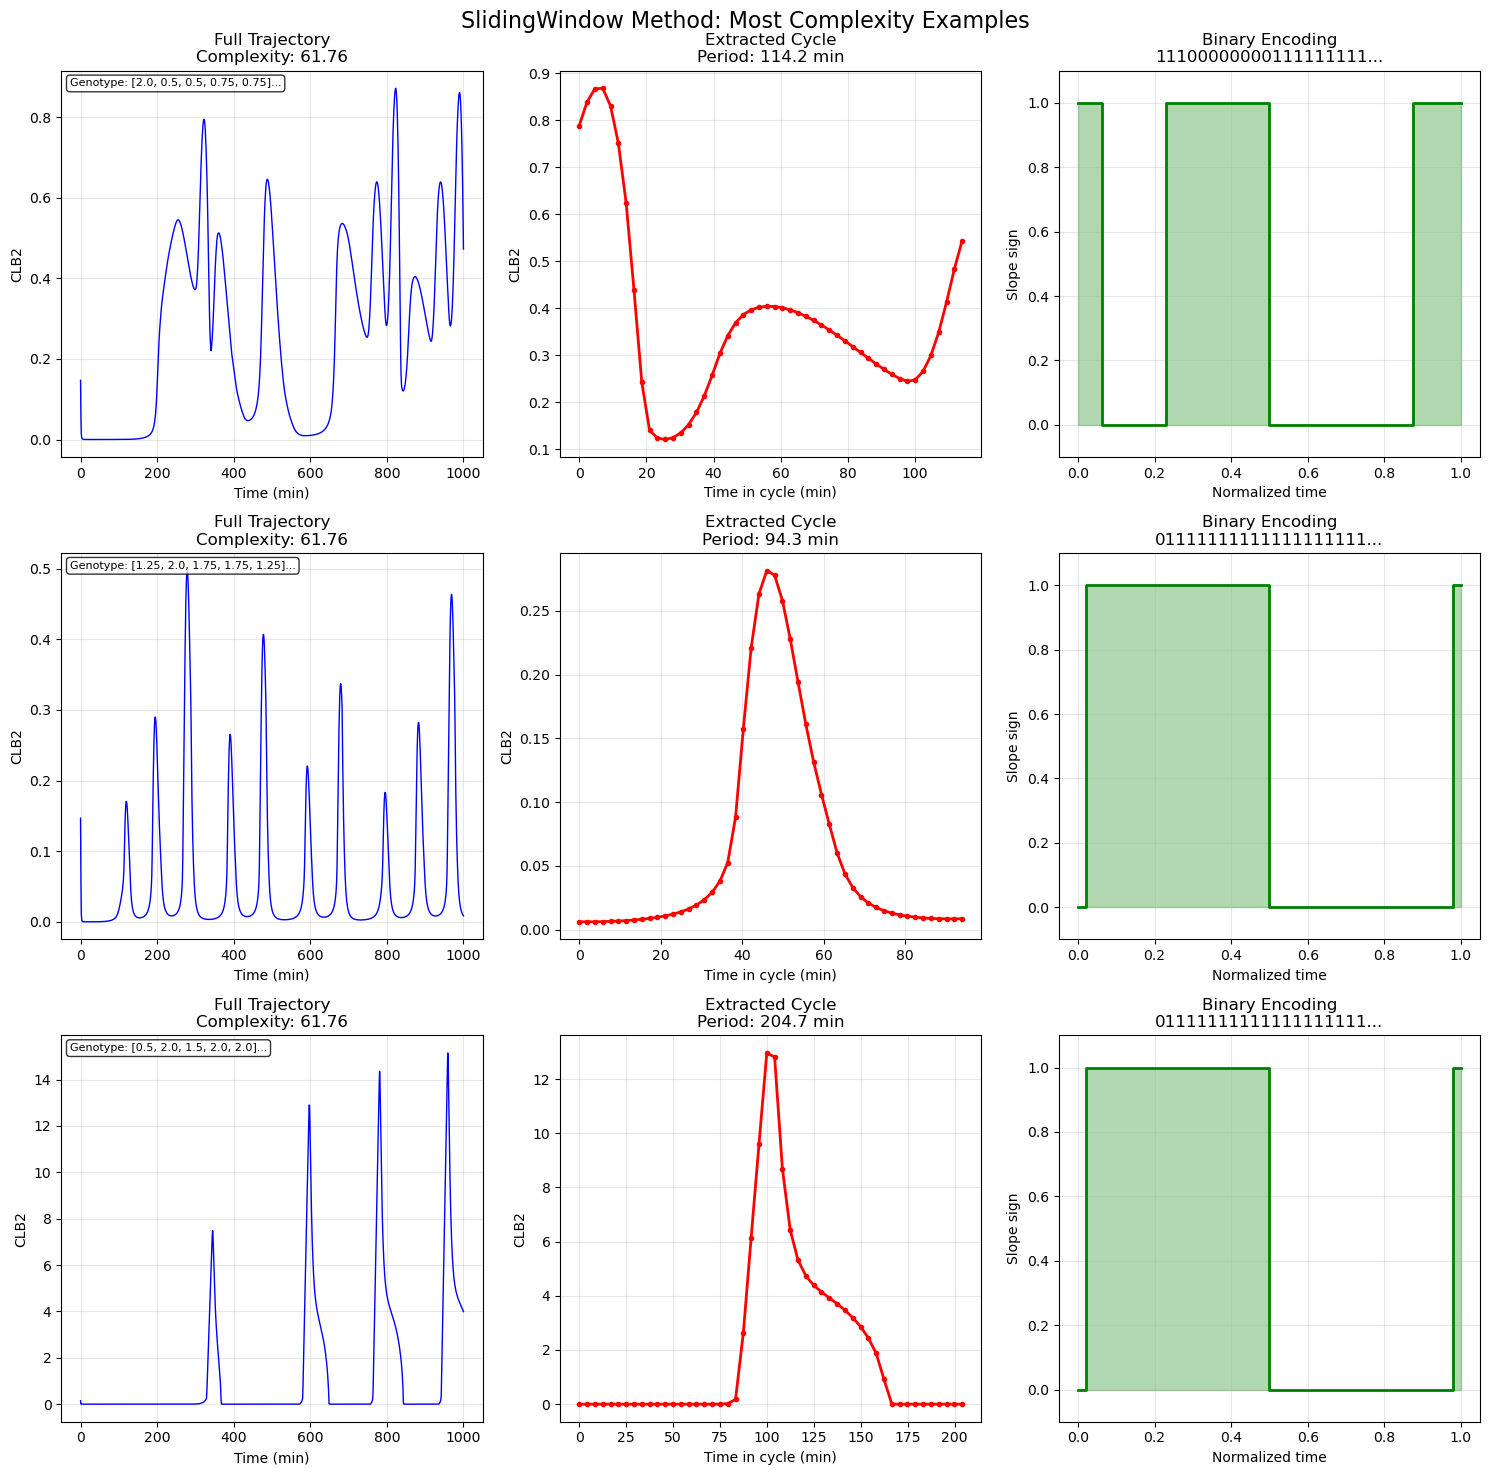

  Saved: comparison_plots/slidingwindow_most_complexity_examples.png

✅ All extreme example visualizations completed


In [78]:
# === VISUALIZATION OF EXTREME EXAMPLES ===
print("\n🎨 Creating visualizations of extreme complexity examples...")

def plot_extreme_examples(method_name, examples, example_type, max_examples=3):
    """Plot examples of extreme complexity oscillations"""
    if not examples:
        return
    
    n_examples = min(len(examples), max_examples)
    
    fig, axes = plt.subplots(n_examples, 3, figsize=(15, 5*n_examples))
    if n_examples == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'{method_name} Method: {example_type} Complexity Examples', fontsize=16)
    
    for i, example in enumerate(examples[:max_examples]):
        data = example['phenotype_data']
        
        # Plot 1: Full trajectory
        axes[i, 0].plot(data['time'], data['clb2'], 'b-', linewidth=1)
        axes[i, 0].set_title(f'Full Trajectory\nComplexity: {example["complexity"]:.2f}')
        axes[i, 0].set_xlabel('Time (min)')
        axes[i, 0].set_ylabel('CLB2')
        axes[i, 0].grid(True, alpha=0.3)
        
        # Plot 2: Extracted cycle
        cycle_time = data['coarse_time'] - data['coarse_time'][0]
        axes[i, 1].plot(cycle_time, data['coarse_signal'], 'ro-', markersize=3, linewidth=2)
        axes[i, 1].set_title(f'Extracted Cycle\nPeriod: {example["period"]:.1f} min')
        axes[i, 1].set_xlabel('Time in cycle (min)')
        axes[i, 1].set_ylabel('CLB2')
        axes[i, 1].grid(True, alpha=0.3)
        
        # Plot 3: Binary encoding
        encoding = example['encoding']
        step_time = np.linspace(0, 1, len(encoding))
        encoding_values = [int(bit) for bit in encoding]
        axes[i, 2].step(step_time, encoding_values, 'g-', linewidth=2, where='post')
        axes[i, 2].fill_between(step_time, 0, encoding_values, step='post', alpha=0.3, color='green')
        axes[i, 2].set_title(f'Binary Encoding\n{encoding[:20]}...')
        axes[i, 2].set_xlabel('Normalized time')
        axes[i, 2].set_ylabel('Slope sign')
        axes[i, 2].set_ylim(-0.1, 1.1)
        axes[i, 2].grid(True, alpha=0.3)
        
        # Add genotype info
        genotype_str = f"Genotype: {example['genotype'][:5]}..."
        axes[i, 0].text(0.02, 0.98, genotype_str, transform=axes[i, 0].transAxes, 
                       va='top', fontsize=8, 
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    filename = f'comparison_plots/{method_name.lower()}_{example_type.lower()}_complexity_examples.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  Saved: {filename}")

# Create plots for each method
for method_name, examples in extreme_examples.items():
    if all_results[method_name]['success_count'] > 0:
        print(f"\nCreating plots for {method_name} method...")
        plot_extreme_examples(method_name, examples['least'], 'Least', 3)
        plot_extreme_examples(method_name, examples['most'], 'Most', 3)

print("\n✅ All extreme example visualizations completed")

In [79]:
# === GENOTYPE ANALYSIS ===
print("\n🧬 Analyzing genotype effects on complexity...")

def analyze_genotype_complexity_relationship(results, method_name):
    """Analyze how genotype parameters relate to phenotype complexity"""
    if results['success_count'] == 0:
        return None
    
    genotypes = np.array(results['genotypes'])
    complexities = np.array(results['complexities'])
    
    # Calculate correlations between parameter values and complexity
    n_params = len(genotypes[0]) if len(genotypes) > 0 else 0
    if n_params == 0:
        return None
    
    correlations = []
    
    for param_idx in range(n_params):
        param_values = genotypes[:, param_idx]
        
        # Calculate correlation
        if len(set(param_values)) > 1:  # Check for variation
            correlation = np.corrcoef(param_values, complexities)[0, 1]
            if not np.isnan(correlation):
                correlations.append((param_idx, correlation))
    
    # Sort by absolute correlation
    correlations.sort(key=lambda x: abs(x[1]), reverse=True)
    
    print(f"\n{method_name} - Parameter-Complexity Correlations:")
    print(f"  Top 5 strongest correlations:")
    for i, (param_idx, correlation) in enumerate(correlations[:5]):
        print(f"    Parameter {param_idx:2d}: r = {correlation:6.3f}")
    
    # Analyze complexity distribution by parameter ranges
    if correlations:
        strongest_param_idx = correlations[0][0]
        strongest_correlation = correlations[0][1]
        
        param_values = genotypes[:, strongest_param_idx]
        
        # Divide into low/high parameter values
        median_param = np.median(param_values)
        low_param_mask = param_values <= median_param
        high_param_mask = param_values > median_param
        
        low_complexities = complexities[low_param_mask]
        high_complexities = complexities[high_param_mask]
        
        print(f"  Parameter {strongest_param_idx} analysis (strongest correlation: {strongest_correlation:.3f}):")
        print(f"    Low values:  mean complexity = {np.mean(low_complexities):.2f} (n={len(low_complexities)})")
        print(f"    High values: mean complexity = {np.mean(high_complexities):.2f} (n={len(high_complexities)})")
        
        return {
            'correlations': correlations,
            'strongest_param': strongest_param_idx,
            'strongest_correlation': strongest_correlation,
            'low_param_complexities': low_complexities,
            'high_param_complexities': high_complexities
        }
    
    return None

# Analyze genotype effects for each method
genotype_analyses = {}
for method_name, results in all_results.items():
    analysis = analyze_genotype_complexity_relationship(results, method_name)
    genotype_analyses[method_name] = analysis

print("\n✅ Genotype analysis completed")


🧬 Analyzing genotype effects on complexity...

Original - Parameter-Complexity Correlations:
  Top 5 strongest correlations:
    Parameter 135: r = -0.170
    Parameter 91: r = -0.129
    Parameter 65: r =  0.124
    Parameter 73: r = -0.124
    Parameter 51: r =  0.092
  Parameter 135 analysis (strongest correlation: -0.170):
    Low values:  mean complexity = 52.97 (n=1020)
    High values: mean complexity = 51.95 (n=466)

Improved - Parameter-Complexity Correlations:
  Top 5 strongest correlations:
    Parameter 65: r =  0.134
    Parameter 135: r = -0.131
    Parameter 120: r = -0.122
    Parameter 78: r =  0.095
    Parameter 108: r = -0.080
  Parameter 65 analysis (strongest correlation: 0.134):
    Low values:  mean complexity = 51.83 (n=1153)
    High values: mean complexity = 53.17 (n=917)

Conservative - Parameter-Complexity Correlations:
  Top 5 strongest correlations:
    Parameter 65: r =  0.173
    Parameter 135: r = -0.133
    Parameter 44: r =  0.124
    Parameter 121:


Threshold - Parameter-Complexity Correlations:
  Top 5 strongest correlations:
    Parameter 65: r =  0.175
    Parameter 73: r = -0.154
    Parameter 91: r = -0.108
    Parameter 111: r = -0.089
    Parameter 61: r =  0.086
  Parameter 65 analysis (strongest correlation: 0.175):
    Low values:  mean complexity = 52.06 (n=1101)
    High values: mean complexity = 53.26 (n=920)

Derivative - Parameter-Complexity Correlations:
  Top 5 strongest correlations:
    Parameter 135: r =  0.307
    Parameter 65: r =  0.225
    Parameter 49: r = -0.120
    Parameter 130: r =  0.092
    Parameter 120: r = -0.091
  Parameter 135 analysis (strongest correlation: 0.307):
    Low values:  mean complexity = 51.73 (n=715)
    High values: mean complexity = 53.88 (n=345)

Adaptive - Parameter-Complexity Correlations:
  Top 5 strongest correlations:
    Parameter 65: r =  0.131
    Parameter 135: r = -0.115
    Parameter 98: r = -0.103
    Parameter 73: r = -0.098
    Parameter 120: r = -0.091
  Paramet

In [80]:
# === FINAL SUMMARY AND CONCLUSIONS ===
print("\n" + "="*80)
print("FINAL SUMMARY: PEAK DETECTION METHODS COMPARISON")
print("="*80)

print("\n📈 SUCCESS RATES:")
for method_name, results in all_results.items():
    success_rate = results['success_count'] / SAMPLING_SIZE * 100
    print(f"  {method_name:12}: {success_rate:6.1f}% ({results['success_count']:,} successful detections)")

print("\n🧮 COMPLEXITY STATISTICS:")
for method_name, results in all_results.items():
    if results['complexities']:
        complexities = results['complexities']
        print(f"  {method_name:12}: mean={np.mean(complexities):5.1f}, std={np.std(complexities):5.1f}, range={min(complexities):5.1f}-{max(complexities):5.1f}")
    else:
        print(f"  {method_name:12}: No successful detections")

print("\n⏱️  PERIOD STATISTICS:")
for method_name, results in all_results.items():
    if results['periods']:
        periods = results['periods']
        print(f"  {method_name:12}: mean={np.mean(periods):6.1f} min, std={np.std(periods):5.1f}, range={min(periods):5.1f}-{max(periods):5.1f}")
    else:
        print(f"  {method_name:12}: No successful detections")

print("\n🎯 KEY FINDINGS:")

# Compare methods
success_rates = {name: results['success_count'] / SAMPLING_SIZE * 100 
                for name, results in all_results.items()}

sorted_methods = sorted(success_rates.items(), key=lambda x: x[1], reverse=True)

print(f"\n1. METHOD RANKING BY SUCCESS RATE:")
for i, (method, rate) in enumerate(sorted_methods):
    print(f"   {i+1}. {method}: {rate:.1f}%")

print(f"\n2. METHOD CHARACTERISTICS:")
print(f"   • Original: Basic prominence-based detection, moderate thresholds")
print(f"   • Improved: Multi-scale + Fourier backup, adaptive smoothing")
print(f"   • Conservative: Strict regularity requirements, higher quality standards")
print(f"   • Simple: Ultra-basic local maxima, very lenient thresholds")
print(f"   • Threshold: Percentile-based peak detection above 75th percentile")
print(f"   • Derivative: Zero-crossing detection in first derivative")
print(f"   • Adaptive: Parameters adapt to signal noise characteristics")
print(f"   • SlidingWindow: Local maxima detection in sliding windows")

print(f"\n3. TRADE-OFFS:")
if 'Conservative' in success_rates and 'Improved' in success_rates:
    conservative_rate = success_rates['Conservative']
    improved_rate = success_rates['Improved']
    
    if improved_rate > conservative_rate:
        print(f"   • Improved method finds {improved_rate - conservative_rate:.1f}% more oscillations")
        print(f"   • Conservative method provides higher quality but fewer detections")
    else:
        print(f"   • Conservative method surprisingly outperformed improved method")

print(f"\n4. GENOTYPE EFFECTS:")
for method_name, analysis in genotype_analyses.items():
    if analysis and analysis['correlations']:
        strongest_corr = analysis['strongest_correlation']
        strongest_param = analysis['strongest_param']
        print(f"   • {method_name}: Parameter {strongest_param} shows strongest correlation (r={strongest_corr:.3f})")

print(f"\n💡 RECOMMENDATIONS:")
best_method = sorted_methods[0][0]
print(f"   • For maximum detection rate: Use {best_method} method")
print(f"   • For highest quality: Use Conservative method (if success rate acceptable)")
print(f"   • For robustness: Use Improved method (good balance of quality and quantity)")

print(f"\n📁 OUTPUT FILES:")
print(f"   • comparison_plots/frequency_complexity_comparison.png")
for method_name in all_results.keys():
    if all_results[method_name]['success_count'] > 0:
        print(f"   • comparison_plots/{method_name.lower()}_least_complexity_examples.png")
        print(f"   • comparison_plots/{method_name.lower()}_most_complexity_examples.png")

print("\n" + "="*80)
print("COMPARISON STUDY COMPLETED SUCCESSFULLY! 🎉")
print("="*80)


FINAL SUMMARY: PEAK DETECTION METHODS COMPARISON

📈 SUCCESS RATES:
  Original    :   14.9% (1,486 successful detections)
  Improved    :   20.7% (2,070 successful detections)
  Conservative:    6.8% (682 successful detections)
  Simple      :   21.1% (2,107 successful detections)
  Threshold   :   20.2% (2,021 successful detections)
  Derivative  :   10.6% (1,060 successful detections)
  Adaptive    :   20.1% (2,006 successful detections)
  SlidingWindow:   21.7% (2,167 successful detections)

🧮 COMPLEXITY STATISTICS:
  Original    : mean= 52.6, std=  3.6, range= 42.1- 61.8
  Improved    : mean= 52.4, std=  5.2, range=  5.6- 67.4
  Conservative: mean= 52.5, std=  3.8, range= 42.1- 64.6
  Simple      : mean= 52.6, std=  3.7, range= 39.3- 61.8
  Threshold   : mean= 52.6, std=  3.7, range= 42.1- 64.6
  Derivative  : mean= 52.4, std=  4.0, range= 42.1- 67.4
  Adaptive    : mean= 52.8, std=  3.6, range= 42.1- 67.4
  SlidingWindow: mean= 52.7, std=  3.6, range= 42.1- 67.4

⏱️  PERIOD STATIS